# **DOMAIN ADAPTATION**

Load the necessary libraries.

In [ ]:
import os
import numpy as np
import soundfile as sf
import librosa
from tqdm import tqdm
import yaml
import pandas as pd
import seaborn as sns
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import confusion_matrix

Load parameters and other configuration values.

In [6]:
# Load audio processing constants from config.yaml
with open("config.yaml", "r") as f:
    config = yaml.safe_load(f)

SAMPLING_RATE = config["audio_processing"]["sampling_rate"] # Resample the audio files with frequency 4 kHz, since wheezes and crackles are typically within frequency range 0–2 kHz
FRAME_LENGTH = config["audio_processing"]["frame_length"] # Use window size of 60 ms for each cycle
HOP_LENGTH = config["audio_processing"]["hop_length"] # Use 50% overlap
N_MFCC = config["audio_processing"]["n_mfcc"] # Extract the first 13 MFCCs
N_MELS = config["audio_processing"]["n_mels"] # Use 64 Mel Banks to extract the Log-Mel Spectrograms

FRAME_SIZE = int(FRAME_LENGTH*SAMPLING_RATE) # Calculate the amount of samples per frame
HOP_SIZE = int(HOP_LENGTH*SAMPLING_RATE) #  Calculate the amount of samples per hop

# Load basic paths from config.yaml
RAW_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["raw_cycle_folder"])
CLEANED_CYCLE_FOLDER = os.path.join(os.getcwd(), config["paths"]["cleaned_cycle_folder"])
TRAINING_SET_FOLDER = os.path.join(os.getcwd(), config["paths"]["training_set_folder"])
TEST_SET_FOLDER = os.path.join(os.getcwd(), config["paths"]["test_set_folder"])

# Feature names 
FEATURE_NAMES = (
    [f"MFCC_{i}" for i in range(N_MFCC)] +
    ["Spectral Centroid", "Spectral Bandwidth", "Zero Crossing Rate", "RMS Energy",
     "Spectral Rolloff", "Spectral Flux", "Spectral Flatness"] 
    + [f"Log Mel_{i}" for i in range(N_MELS)] + ["On Set Envelope"]
)

# Number of features used
N_FEATURES = len(FEATURE_NAMES) 

# Device names 
DEVICES = ["AKGC417L", "LittC2SE", "Litt3200", "Meditron"]
REFERENCE_DEVICE = "Meditron"

# Neural networks configurations
BOTTLENECK = config["domain_adaptation"]["bottleneck_dim"]
LATENT = config["domain_adaptation"]["latent_dim"]
BATCH_SIZE = config["domain_adaptation"]["batch_size"]

In [7]:
# Load training and test sets
train_df = pd.read_csv(os.path.join(TRAINING_SET_FOLDER, "raw_training_set.csv"))
final_train_df = pd.read_csv(os.path.join(TRAINING_SET_FOLDER, "training_set.csv"))
augmented_labels_df = pd.read_csv(os.path.join(TRAINING_SET_FOLDER, "augmented_training_set.csv"))
test_df = pd.read_csv(os.path.join(TEST_SET_FOLDER, "test_set.csv"))

### **DOMAIN SHIFT DETECTION**

We first plot the distribution of the final respiratory cycles after preprocessing and VTLP-Patch augmentation per device.

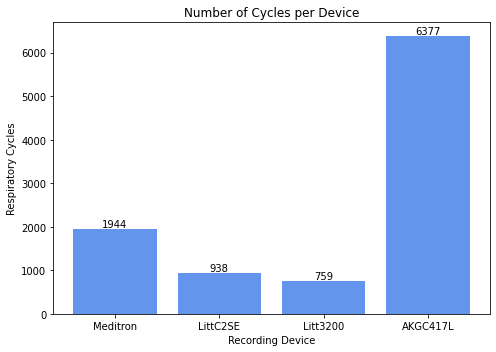

In [6]:
device_counts = Counter()

# Count the initial respiratory cycles of each device
for fname in os.listdir(CLEANED_CYCLE_FOLDER):
    if fname.endswith(".wav"):
        matched_device = next((d for d in DEVICES if d in fname), None)
        if matched_device:
            device_counts[matched_device] += 1

# Bar plot
plt.figure(figsize=(7, 5))
plt.bar(device_counts.keys(), device_counts.values(), color="cornflowerblue")
plt.title("Number of Cycles per Device")
plt.xlabel("Recording Device")
plt.ylabel("Respiratory Cycles")

for i, (device, count) in enumerate(device_counts.items()):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [5]:
# Extract device names from training filenames 
device_labels = []
for fname in final_train_df['file']:
    matched_device = next((d for d in DEVICES if d in fname), None)
    device_labels.append(matched_device)

np.save("training_devices.npy", np.array(device_labels))

In [6]:
# Extract device names from test filenames 
device_labels = []
for fname in test_df['file']:
    matched_device = next((d for d in DEVICES if d in fname), None)
    device_labels.append(matched_device)

np.save("test_devices.npy", np.array(device_labels))

We also plot the class x device table for the respiratory cycles of both training and test sets.

In [20]:
train_df["device"] = train_df["file"].apply(
    lambda fname: next((d for d in DEVICES if d in fname), "Unknown")
)

device_class_counts = (
    train_df.groupby(["class", "device"])
    .size()
    .unstack()
    .fillna(0)
    .astype(int)
)

print(device_class_counts)

device   AKGC417L  Litt3200  LittC2SE  Meditron
class                                          
Crackle      1234        22        64       171
Normal       1537       266       287       823
Wheeze        401        88        98       122


In [4]:
test_df["device"] = test_df["file"].apply(
    lambda fname: next((d for d in DEVICES if d in fname), "Unknown")
)

device_class_counts = (
    test_df.groupby(["class", "device"])
    .size()
    .unstack()
    .fillna(0)
    .astype(int)
)

print(device_class_counts)

device   AKGC417L  Litt3200  LittC2SE  Meditron
class                                          
Crackle       309         7        13        44
Normal        385        70        60       214
Wheeze         99        24        28        26


Then, we plot the KDE plots, boxplots and PCA, t-SNE of the training set features. 

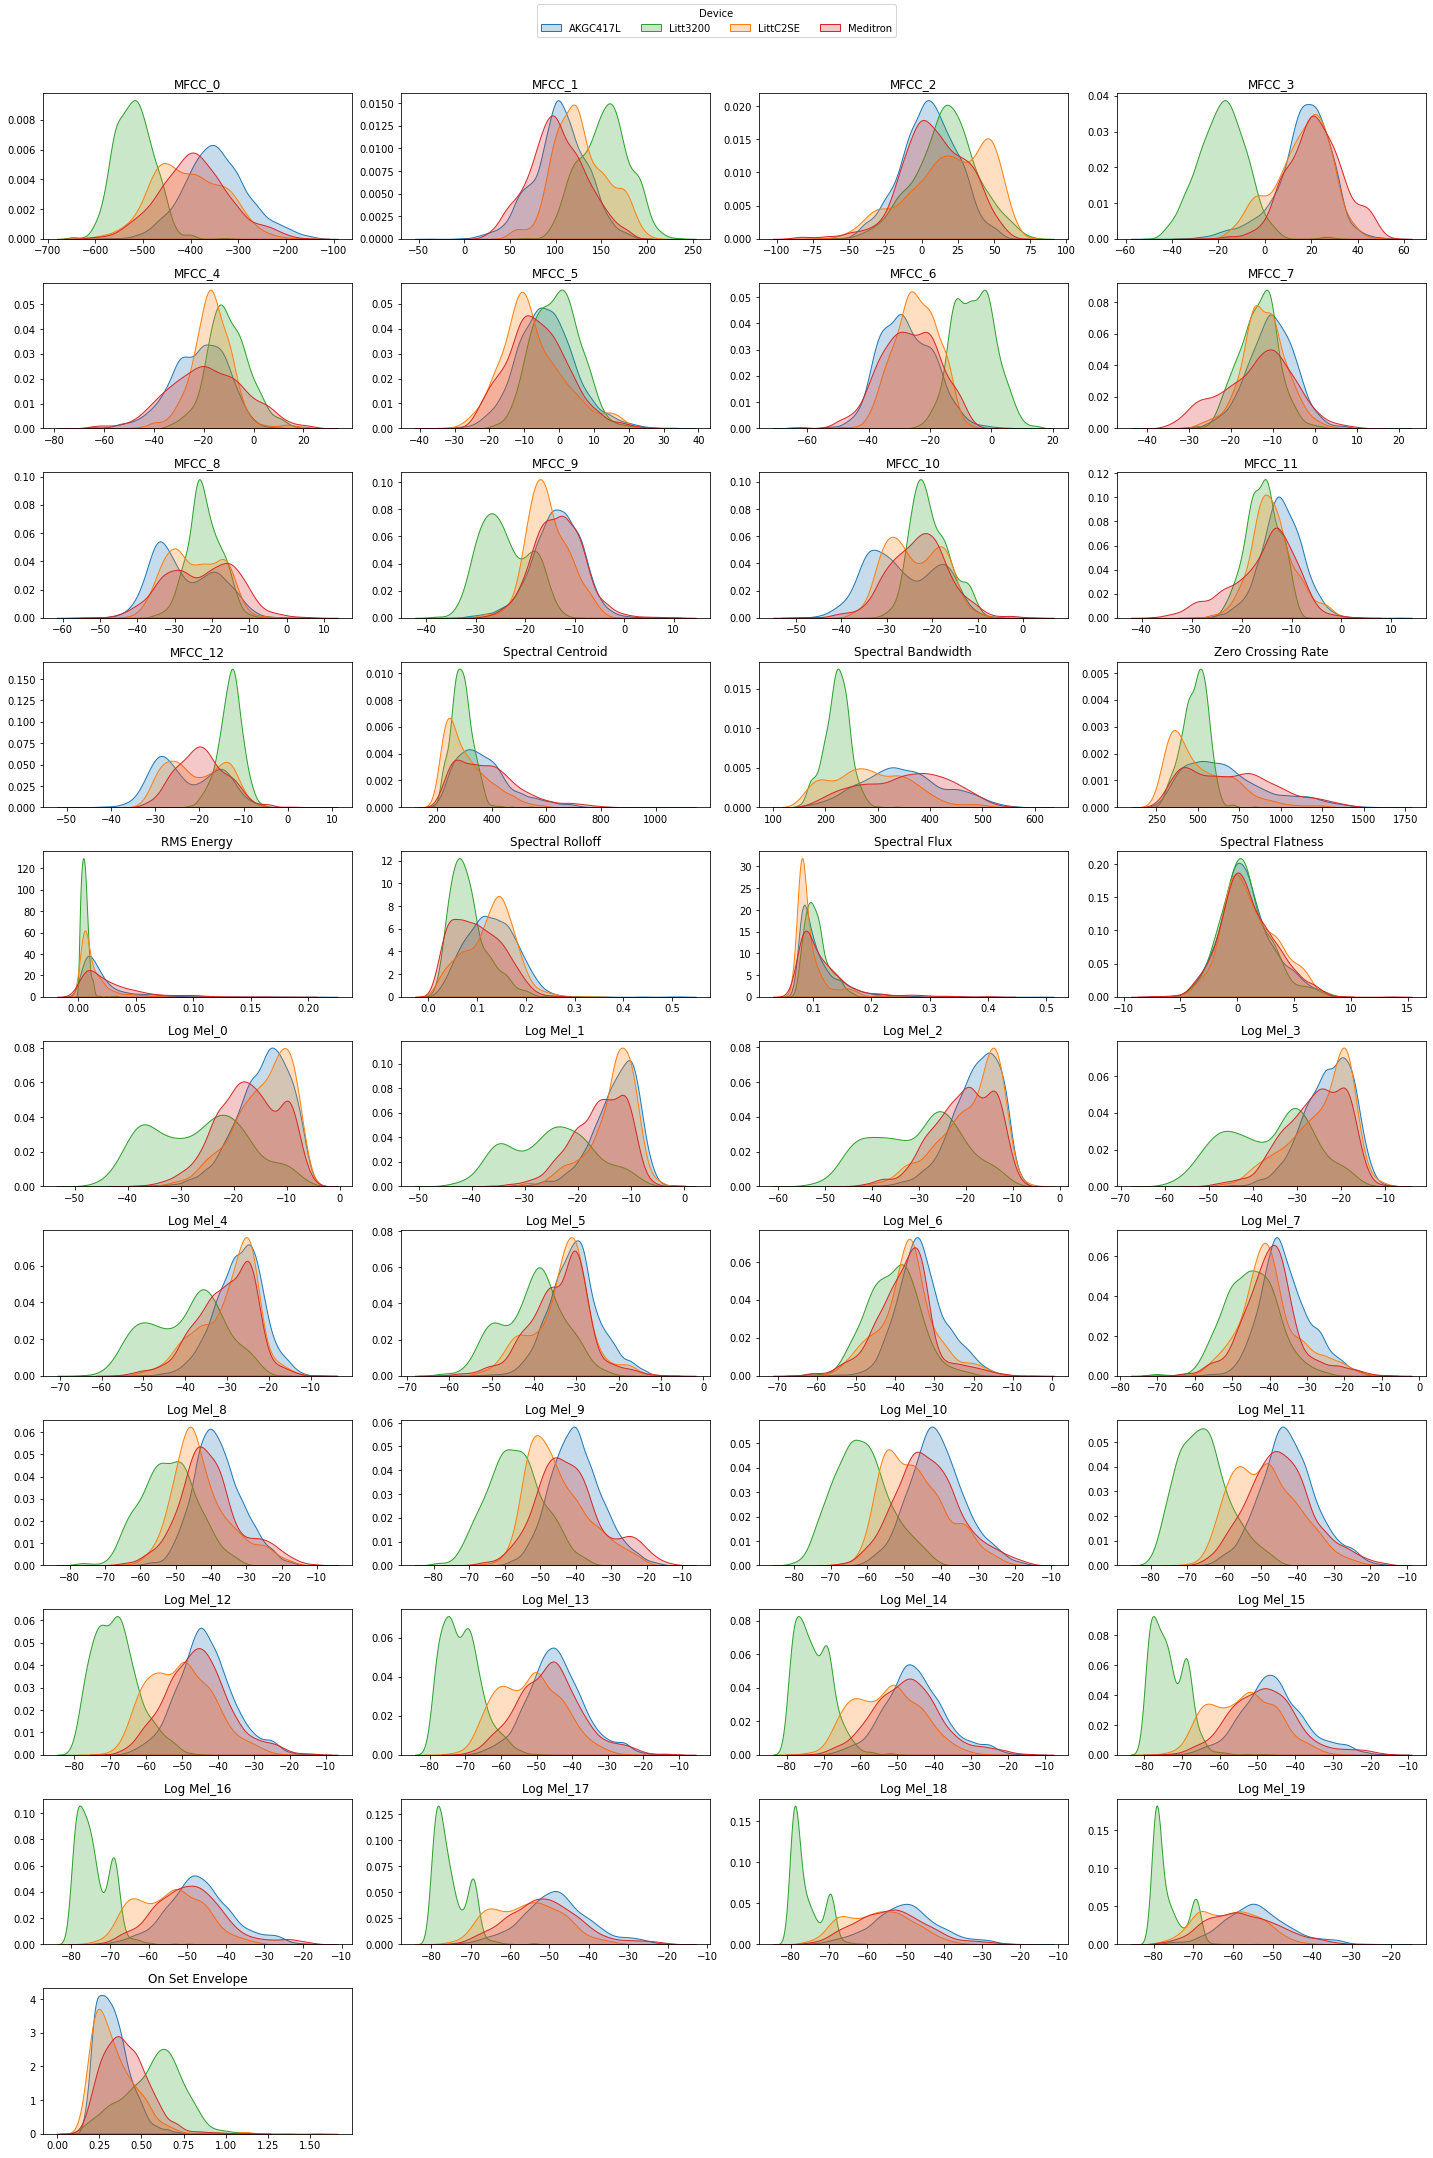

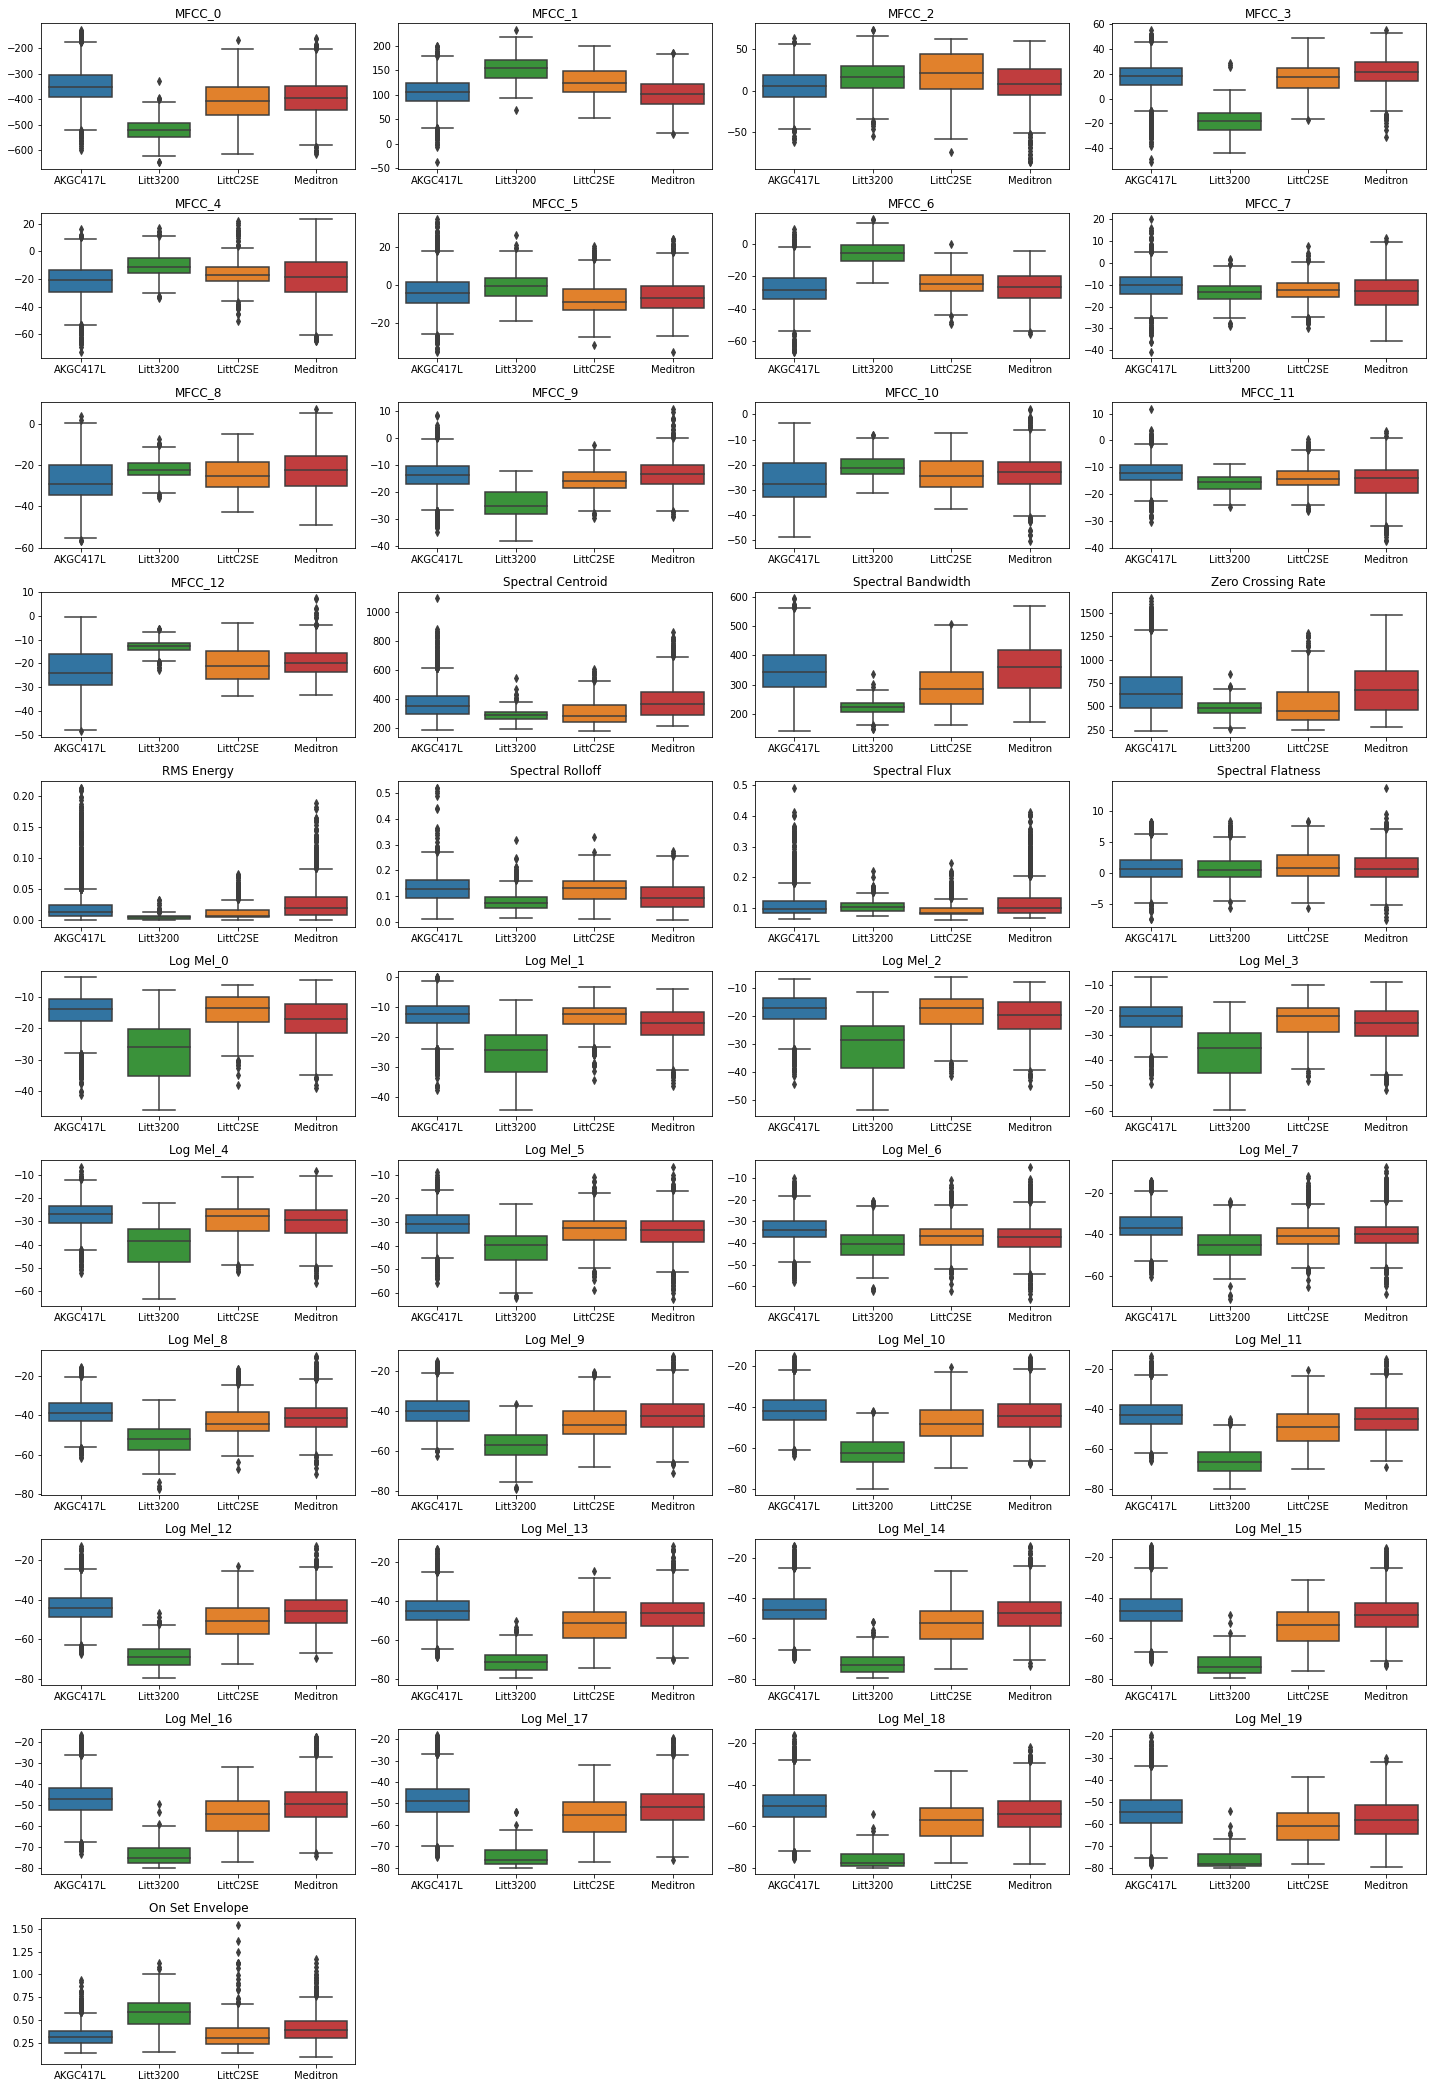

In [426]:
from utils.plots import plot_feature_distributions_by_device

# Load training set data
training_features_mean = np.load("training_features_mean.npy")  
training_devices = np.load("training_devices.npy")  

plot_feature_distributions_by_device(training_features_mean, training_devices, FEATURE_NAMES)

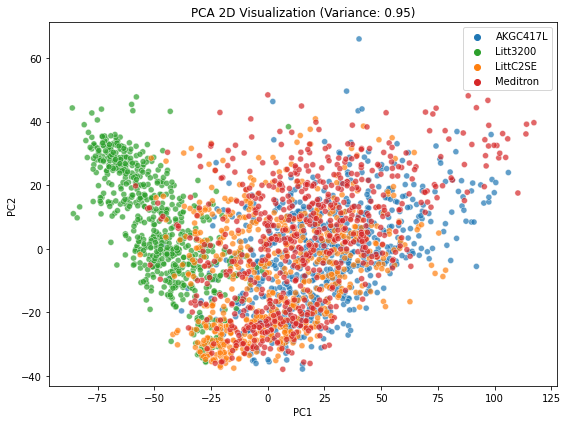

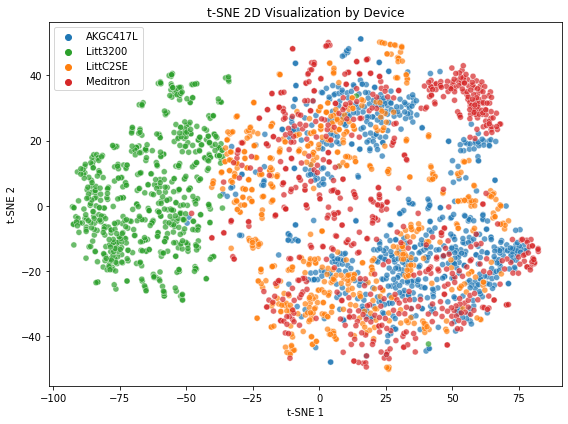

In [9]:
from utils.plots import perform_pca_and_tsne_by_device

training_features_flattened = np.load("training_features_flattened.npy")

# Count samples per device
device_counts = Counter(training_devices)
min_count = min(device_counts.values())  # minimum class count

# Select balanced subset by resampling
balanced_training_features = []
balanced_device_labels = []

for device in np.unique(training_devices):
    training_features_dev = training_features_flattened[training_devices == device]
    training_features_bal = resample(training_features_dev, replace=False, n_samples=min_count, random_state=0)
    balanced_training_features.append(training_features_bal)
    balanced_device_labels.extend([device] * len(training_features_bal))

balanced_training_features = np.vstack(balanced_training_features)
balanced_device_labels = np.array(balanced_device_labels)

perform_pca_and_tsne_by_device(
    balanced_training_features,
    balanced_device_labels,
    pca_components=0.95,  
    tsne_components=2,
    perplexity=30,
    feature_names=FEATURE_NAMES,
    plot_feature_contribution=False
)

Detect the existing domain shift using a simple statistical Domain Classifier.

Accuracy per fold: [0.8216 0.7875 0.7814 0.8251 0.8061]
Mean accuracy: 0.8043 ± 0.0176


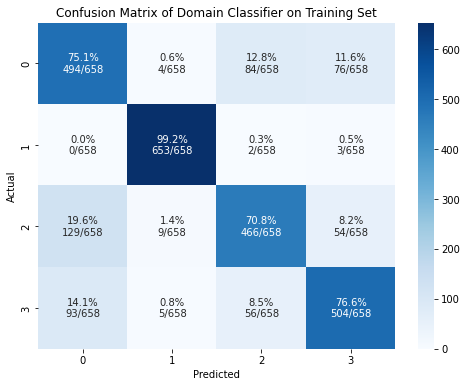

In [10]:
# Encode device labels
le = LabelEncoder()
y = le.fit_transform(balanced_device_labels)
device_names = le.classes_

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(balanced_training_features)

# Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
print("Accuracy per fold:", np.round(scores, 4))
print("Mean accuracy: {:.4f} ± {:.4f}".format(scores.mean(), scores.std()))

# Predictions for confusion matrix
y_pred = cross_val_predict(clf, X, y, cv=cv)

# Confusion matrix
cm = confusion_matrix(y, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

labels = np.array([
    [f"{cm_norm[i, j]*100:.1f}%\n{cm[i, j]}/{cm.sum(axis=1)[i]}" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Domain Classifier on Training Set")
plt.show()

The analysis reveals that there is a moderate domain shift between devices in the dataset. This is supported by two key observations: 

(1) the PCA and t-SNE visualizations show partial clustering by device, with some overlap but also noticeable separation — particularly for certain devices like Litt3200 

(2) the domain classifier achieves an accuracy of approximately 80% on a balanced dataset, which is significantly higher than random guessing (25%). This indicates that device identity influences the feature space.

### **DOMAIN ADAPTATION APPROACHES**

#### **SPECTRUM CORRECTION**

Fit Spectrum Correction on the raw trining data.

In [27]:
from domain_adaptation_algorithms.spectrum_correction import *

device_segments = {device: [] for device in DEVICES}

for _, row in train_df.iterrows():
    fname = row["file"]
    device = next((d for d in DEVICES if d in fname), None)
    if device:
        path = os.path.join(RAW_CYCLE_FOLDER, fname)
        y, _ = librosa.load(path, sr=SAMPLING_RATE)
        device_segments[device].append(y)

# Create aligned segments 
min_len = min(len(v) for v in device_segments.values())
aligned_segments = []

for i in range(min_len):
    segment = {}
    for device in DEVICES:
        segment[device] = device_segments[device][i]
    aligned_segments.append(segment)

# Fit SpectrumCorrection on raw training data
correction = SpectrumCorrection(num_fft=FRAME_SIZE, hop_length=HOP_SIZE)
correction.fit(aligned_segments, reference=REFERENCE_DEVICE)

Plot the correction coefficients that are created after the fitting.

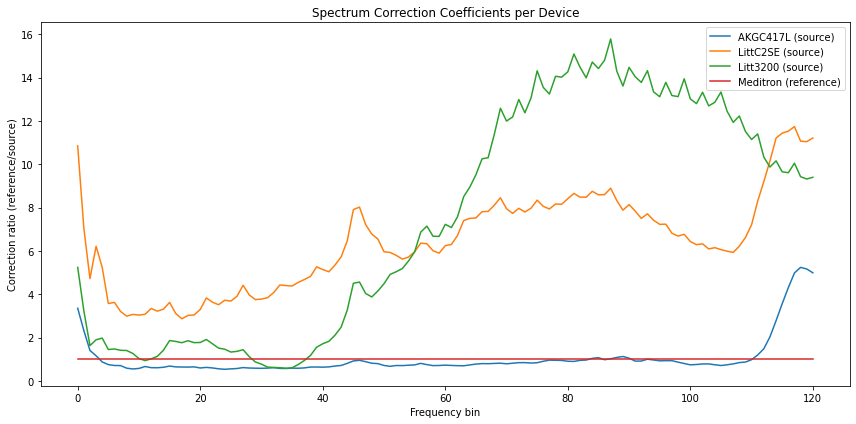

In [14]:
color_map = {
    'AKGC417L': '#1f77b4',   
    'Litt3200': '#2ca02c',   
    'LittC2SE': '#ff7f0e',   
    'Meditron': '#d62728'    
}

plt.figure(figsize=(12, 6))

for device, coeffs in correction.coefficients.items():
    if device == REFERENCE_DEVICE:
        continue
    plt.plot(
        coeffs,
        label=f"{device} (source)",
        color=color_map.get(device, None)
    )

num_bins = len(next(iter(correction.coefficients.values())))
plt.plot(
    np.ones(num_bins),
    label=f"{REFERENCE_DEVICE} (reference)",
    color=color_map[REFERENCE_DEVICE],
    linestyle='-'
)

plt.title("Spectrum Correction Coefficients per Device")
plt.xlabel("Frequency bin")
plt.ylabel("Correction ratio (reference/source)")
plt.legend()
plt.tight_layout()
plt.show()

Apply Spectrum Correction using the calculated correction coefficents and create the new .wav files for the respiratory cycles using Inverse Fourier Transform.

In [14]:
SC_TRAIN_FOLDER = "corrected_train_sc"
os.makedirs(SC_TRAIN_FOLDER, exist_ok=True)

# Apply Spectrum Correction only on non-reference devices of preprocessed training set 
for fname in tqdm(final_train_df["file"], desc="Applying Spectrum Correction on training set"):
    device = next((d for d in DEVICES if d in fname), None)
    input_path = os.path.join(CLEANED_CYCLE_FOLDER, fname)
    output_path = os.path.join(SC_TRAIN_FOLDER, fname)

    y, _ = librosa.load(input_path, sr=SAMPLING_RATE)
    if device != REFERENCE_DEVICE:
        y = correction.transform_wave(y, device)

    sf.write(output_path, y, SAMPLING_RATE)

Applying Spectrum Correction on training set: 100%|██████████| 8739/8739 [01:04<00:00, 134.75it/s]


In [15]:
SC_TEST_FOLDER = "corrected_test_sc"
os.makedirs(SC_TEST_FOLDER, exist_ok=True)

# Apply Spectrum Correction only on non-reference devices of testing set 
for fname in tqdm(test_df["file"], desc="Applying Spectrum Correction on test set"):
    device = next((d for d in DEVICES if d in fname), None)
    input_path = os.path.join(CLEANED_CYCLE_FOLDER, fname)
    output_path = os.path.join(SC_TEST_FOLDER, fname)

    y, _ = librosa.load(input_path, sr=SAMPLING_RATE)
    if device != REFERENCE_DEVICE:
        y = correction.transform_wave(y, device)

    sf.write(output_path, y, SAMPLING_RATE)

Applying Spectrum Correction on test set: 100%|██████████| 1279/1279 [00:10<00:00, 124.75it/s]


Plot some respiratory cycles before and after to visualize the effect of Spectrum Correction.

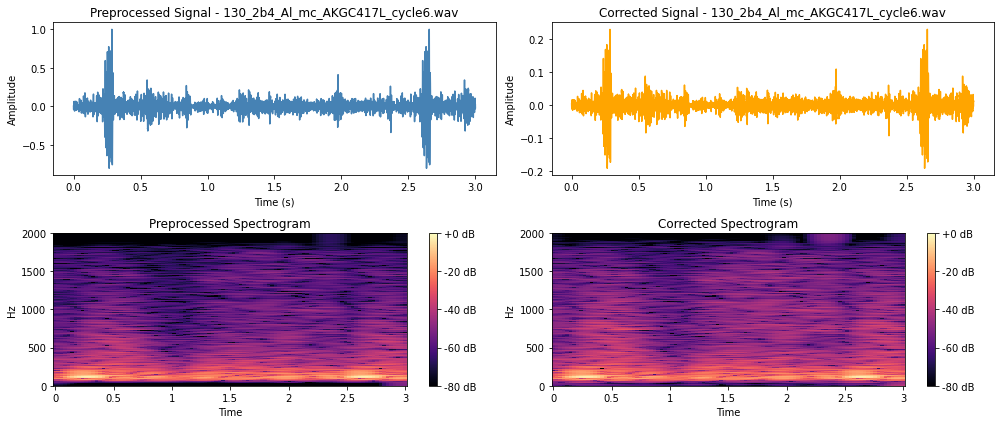

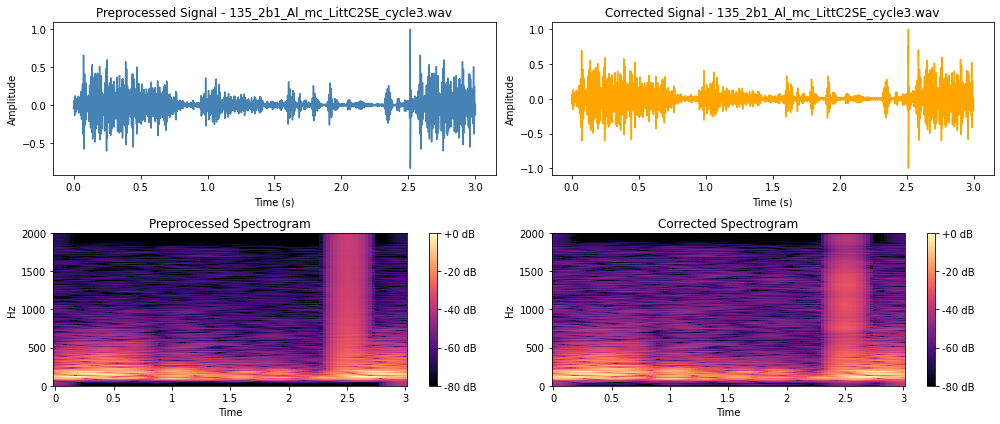

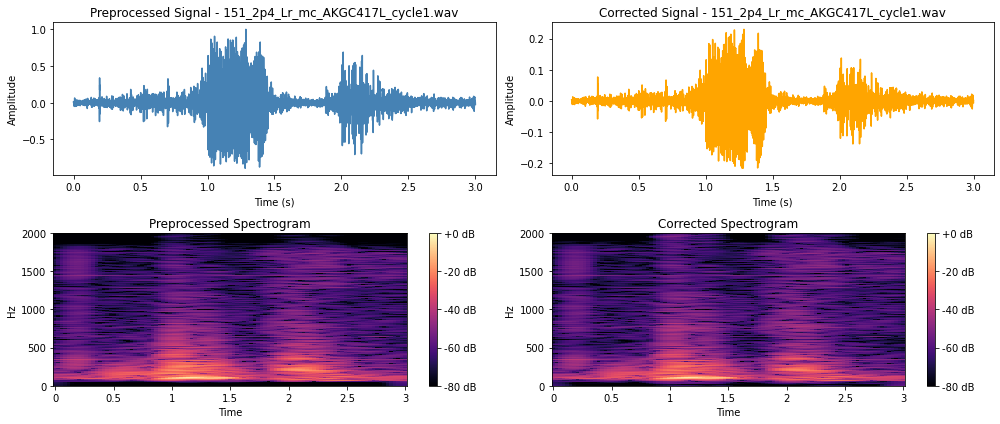

In [52]:
from utils.plots import plot_signals_after_domain_adaptation

# Get the first 3 .wav files that do not originate from the reference device and plot them
non_ref_train_files = final_train_df[~final_train_df["file"].str.contains(REFERENCE_DEVICE)]["file"].tolist()[:3]

plot_signals_after_domain_adaptation(
    file_list=non_ref_train_files,
    cleaned_folder=CLEANED_CYCLE_FOLDER,
    corrected_folder=SC_TRAIN_FOLDER,
    sampling_rate=SAMPLING_RATE,
    hop_size=HOP_SIZE
)

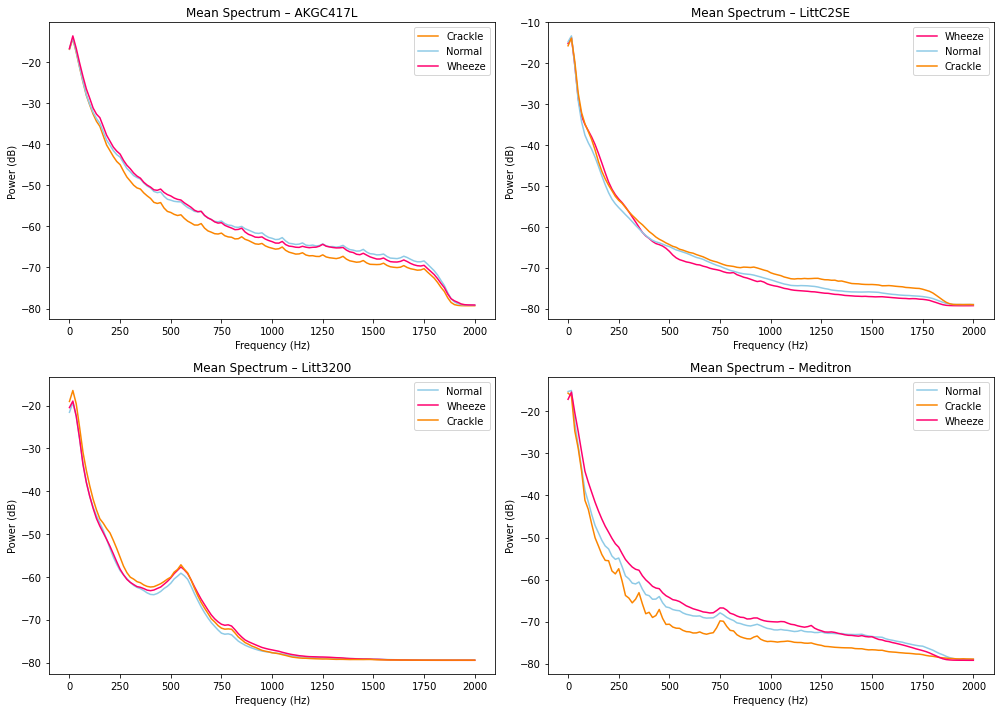

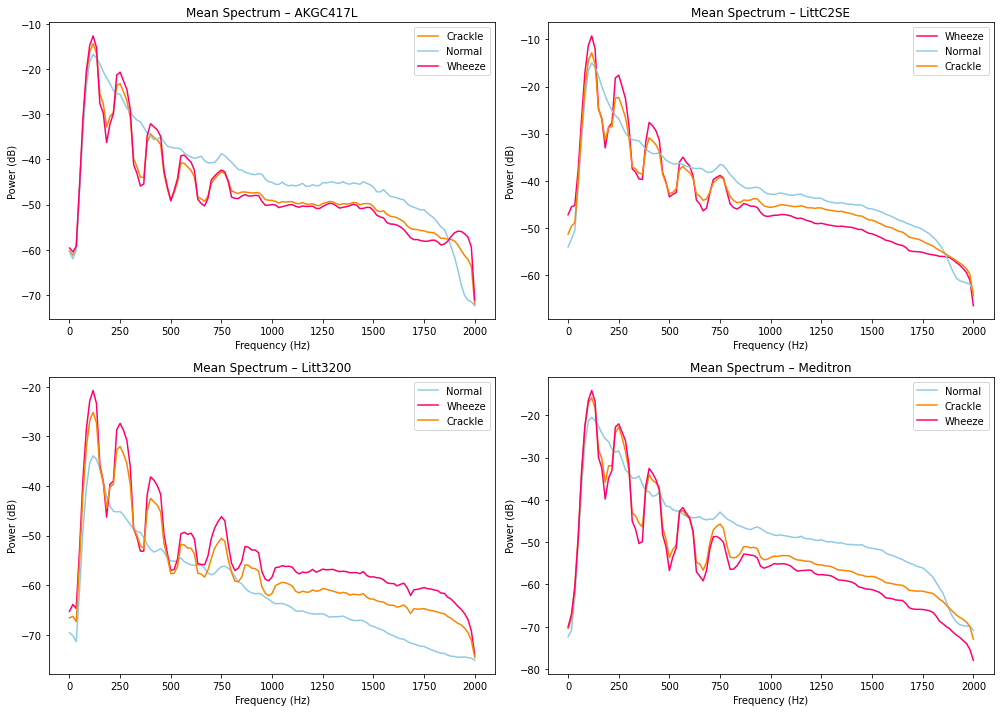

In [17]:
from utils.plots import plot_mean_spectra_per_device

plot_mean_spectra_per_device(
    folder=RAW_CYCLE_FOLDER,
    df=final_train_df,
    devices=DEVICES,
    sampling_rate=SAMPLING_RATE,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE
)

plot_mean_spectra_per_device(
    folder=SC_TRAIN_FOLDER,
    df=final_train_df,
    devices=DEVICES,
    sampling_rate=SAMPLING_RATE,
    frame_size=FRAME_SIZE,
    hop_size=HOP_SIZE
)

Extract the new acoustic features from the corrected .wav files.

In [16]:
from utils.audio_preprocessing import extract_acoustic_features

# Mapping filename to label 
filename_to_label = dict(zip(final_train_df["file"], final_train_df["class"]))

train_feature_list = []
train_filename_list = []
train_label_list = []

train_wav_files = [f for f in os.listdir(SC_TRAIN_FOLDER) if f.endswith(".wav")]

for fname in tqdm(train_wav_files, desc="Extracting features from corrected training set"):
    path = os.path.join(SC_TRAIN_FOLDER, fname)
    y, sr = librosa.load(path, sr=SAMPLING_RATE)

    feats = extract_acoustic_features(
        y, sr,
        frame_size=FRAME_SIZE,
        hop_size=HOP_SIZE,
        n_mfcc=N_MFCC,
        n_mels=N_MELS
    )

    train_feature_list.append(feats)
    train_filename_list.append(fname)

    label = filename_to_label.get(fname)
    if label is None:
        print(f"[Warning] No label found for {fname}")
    train_label_list.append(label)

# Convert to arrays
train_features_array = np.stack(train_feature_list)
train_filenames_array = np.array(train_filename_list)
train_labels_array = np.array(train_label_list)

train_features_mean = train_features_array.mean(axis=1)  # shape: (cycles, features)

np.save("training_features_sc.npy", train_features_mean)
np.save("training_filenames_sc.npy", train_filenames_array)
np.save("training_labels_sc.npy", train_labels_array)

Extracting features from corrected training set: 100%|██████████| 8739/8739 [03:09<00:00, 46.11it/s]


In [17]:
# Mapping filename to label 
filename_to_label = dict(zip(test_df["file"], test_df["class"]))

test_feature_list = []
test_filename_list = []
test_label_list = []

test_wav_files = [f for f in os.listdir(SC_TEST_FOLDER) if f.endswith(".wav")]

for fname in tqdm(test_wav_files, desc="Extracting features from corrected test set"):
    path = os.path.join(SC_TEST_FOLDER, fname)
    y, sr = librosa.load(path, sr=SAMPLING_RATE)

    feats = extract_acoustic_features(
        y, sr,
        frame_size=FRAME_SIZE,
        hop_size=HOP_SIZE,
        n_mfcc=N_MFCC,
        n_mels=N_MELS
    )

    test_feature_list.append(feats)
    test_filename_list.append(fname)

    label = filename_to_label.get(fname)
    if label is None:
        print(f"[Warning] No label found for {fname}")
    test_label_list.append(label)

# Convert to arrays 
test_features_array = np.stack(test_feature_list)
test_filenames_array = np.array(test_filename_list)
test_labels_array = np.array(test_label_list)

test_features_mean = test_features_array.mean(axis=1)  # shape: (cycles, features)

np.save("test_features_sc.npy", test_features_mean)
np.save("test_filenames_sc.npy", test_filenames_array)
np.save("test_labels_sc.npy", test_labels_array)

Extracting features from corrected test set: 100%|██████████| 1279/1279 [00:28<00:00, 44.50it/s]


Visualize the distributions of the new features using KDE and Boxplots.

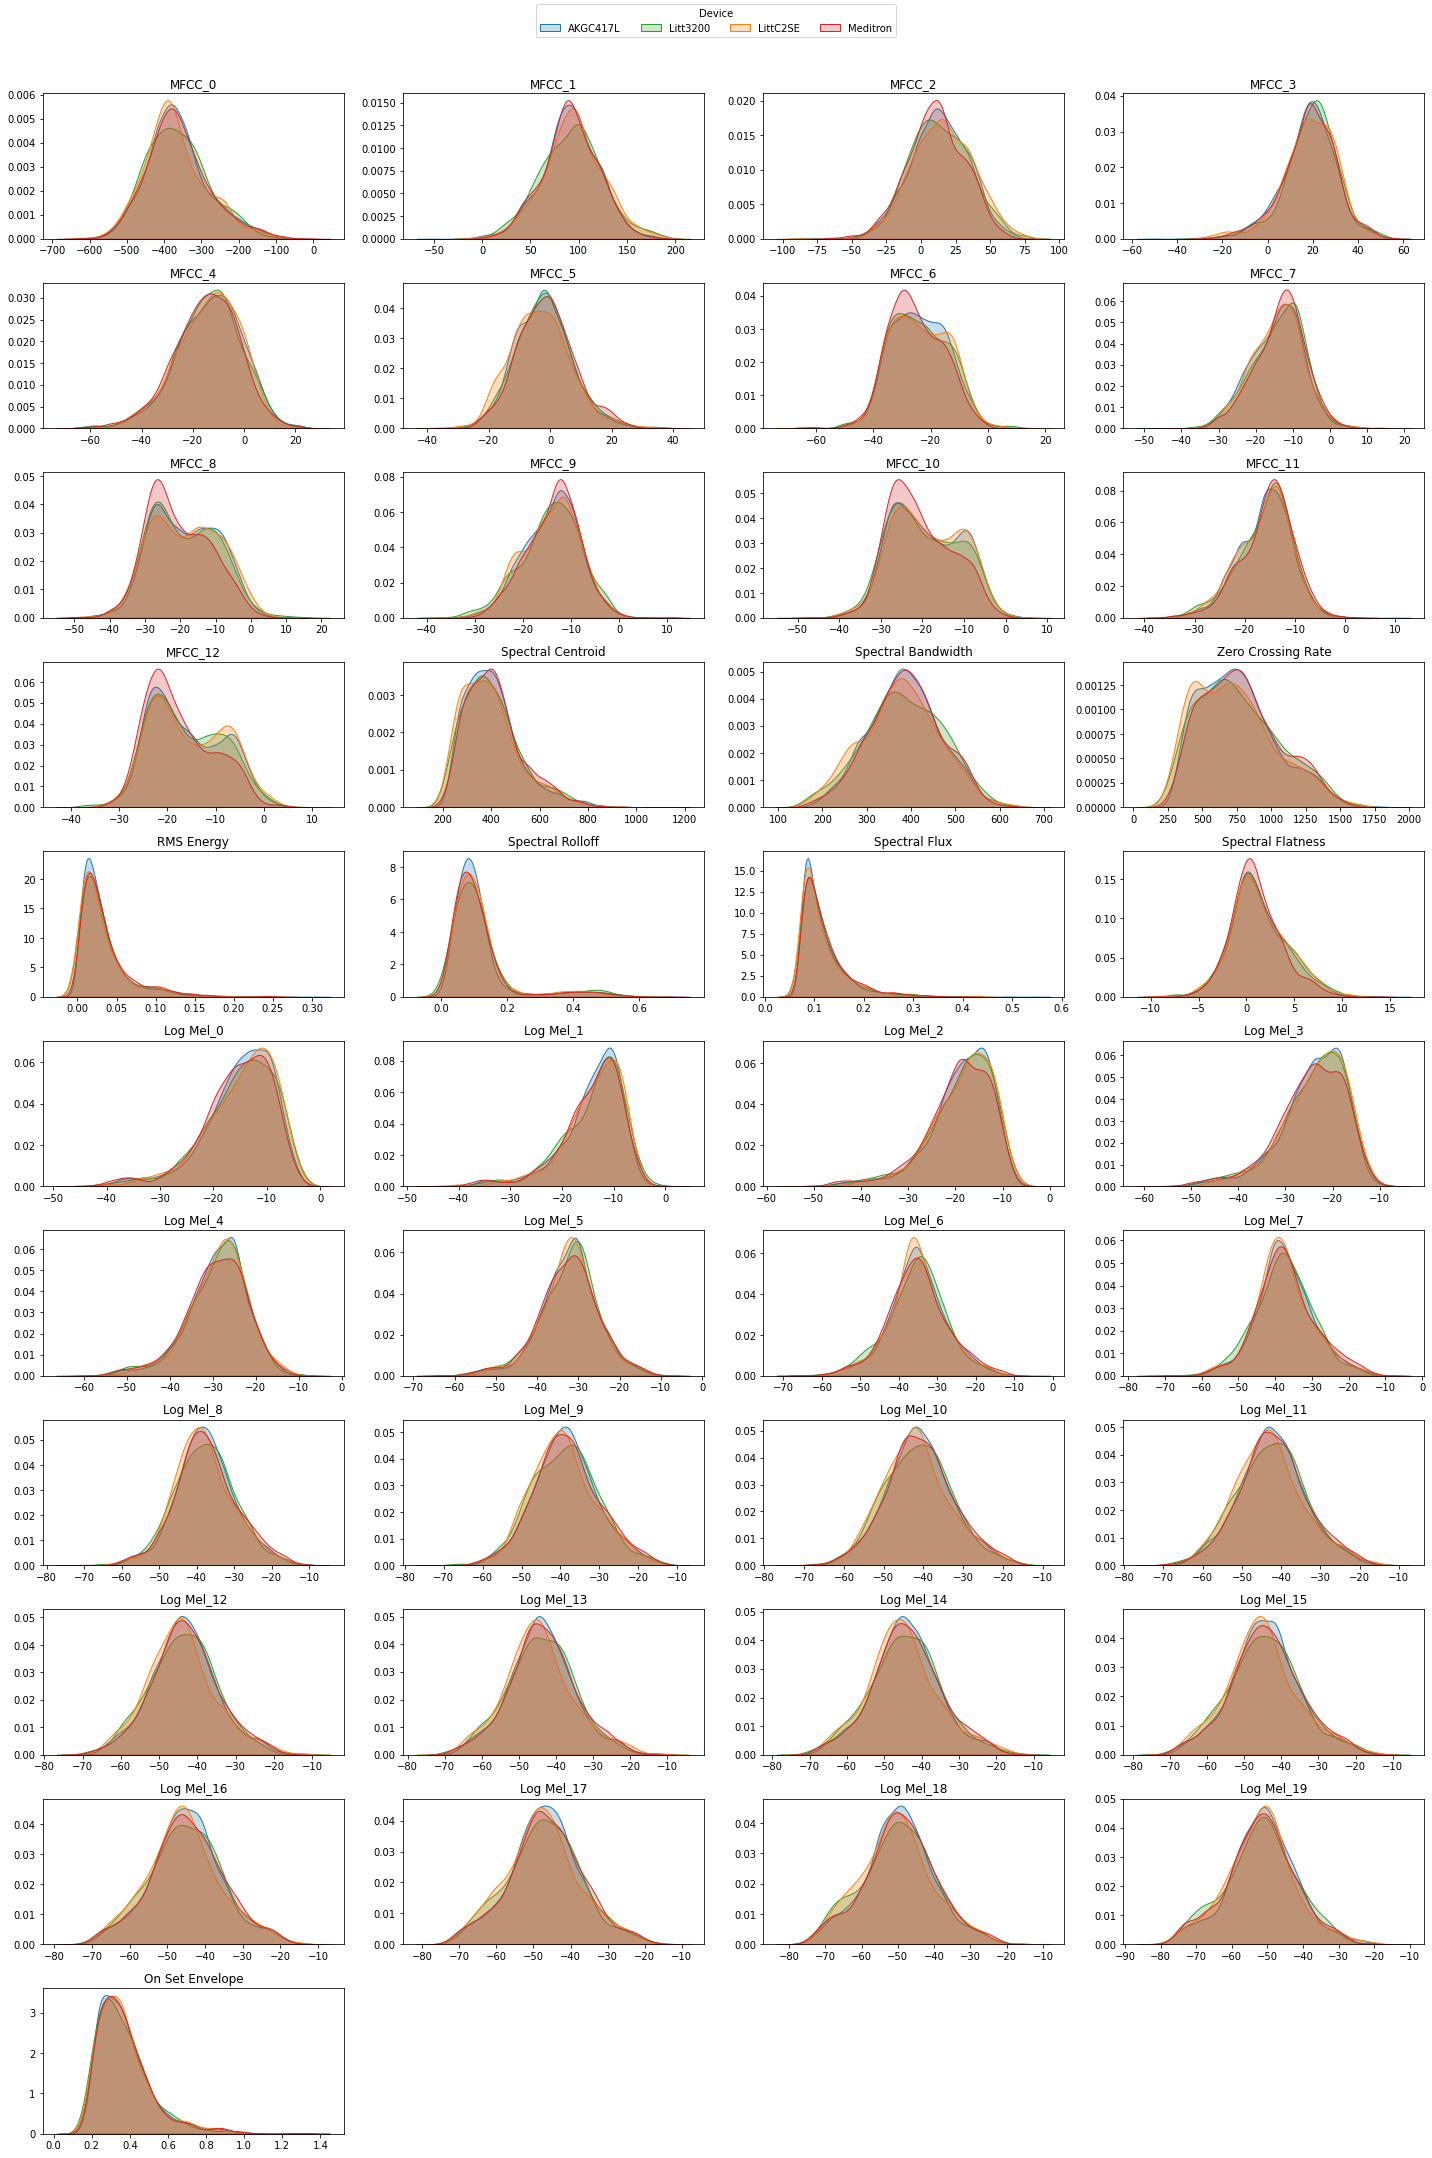

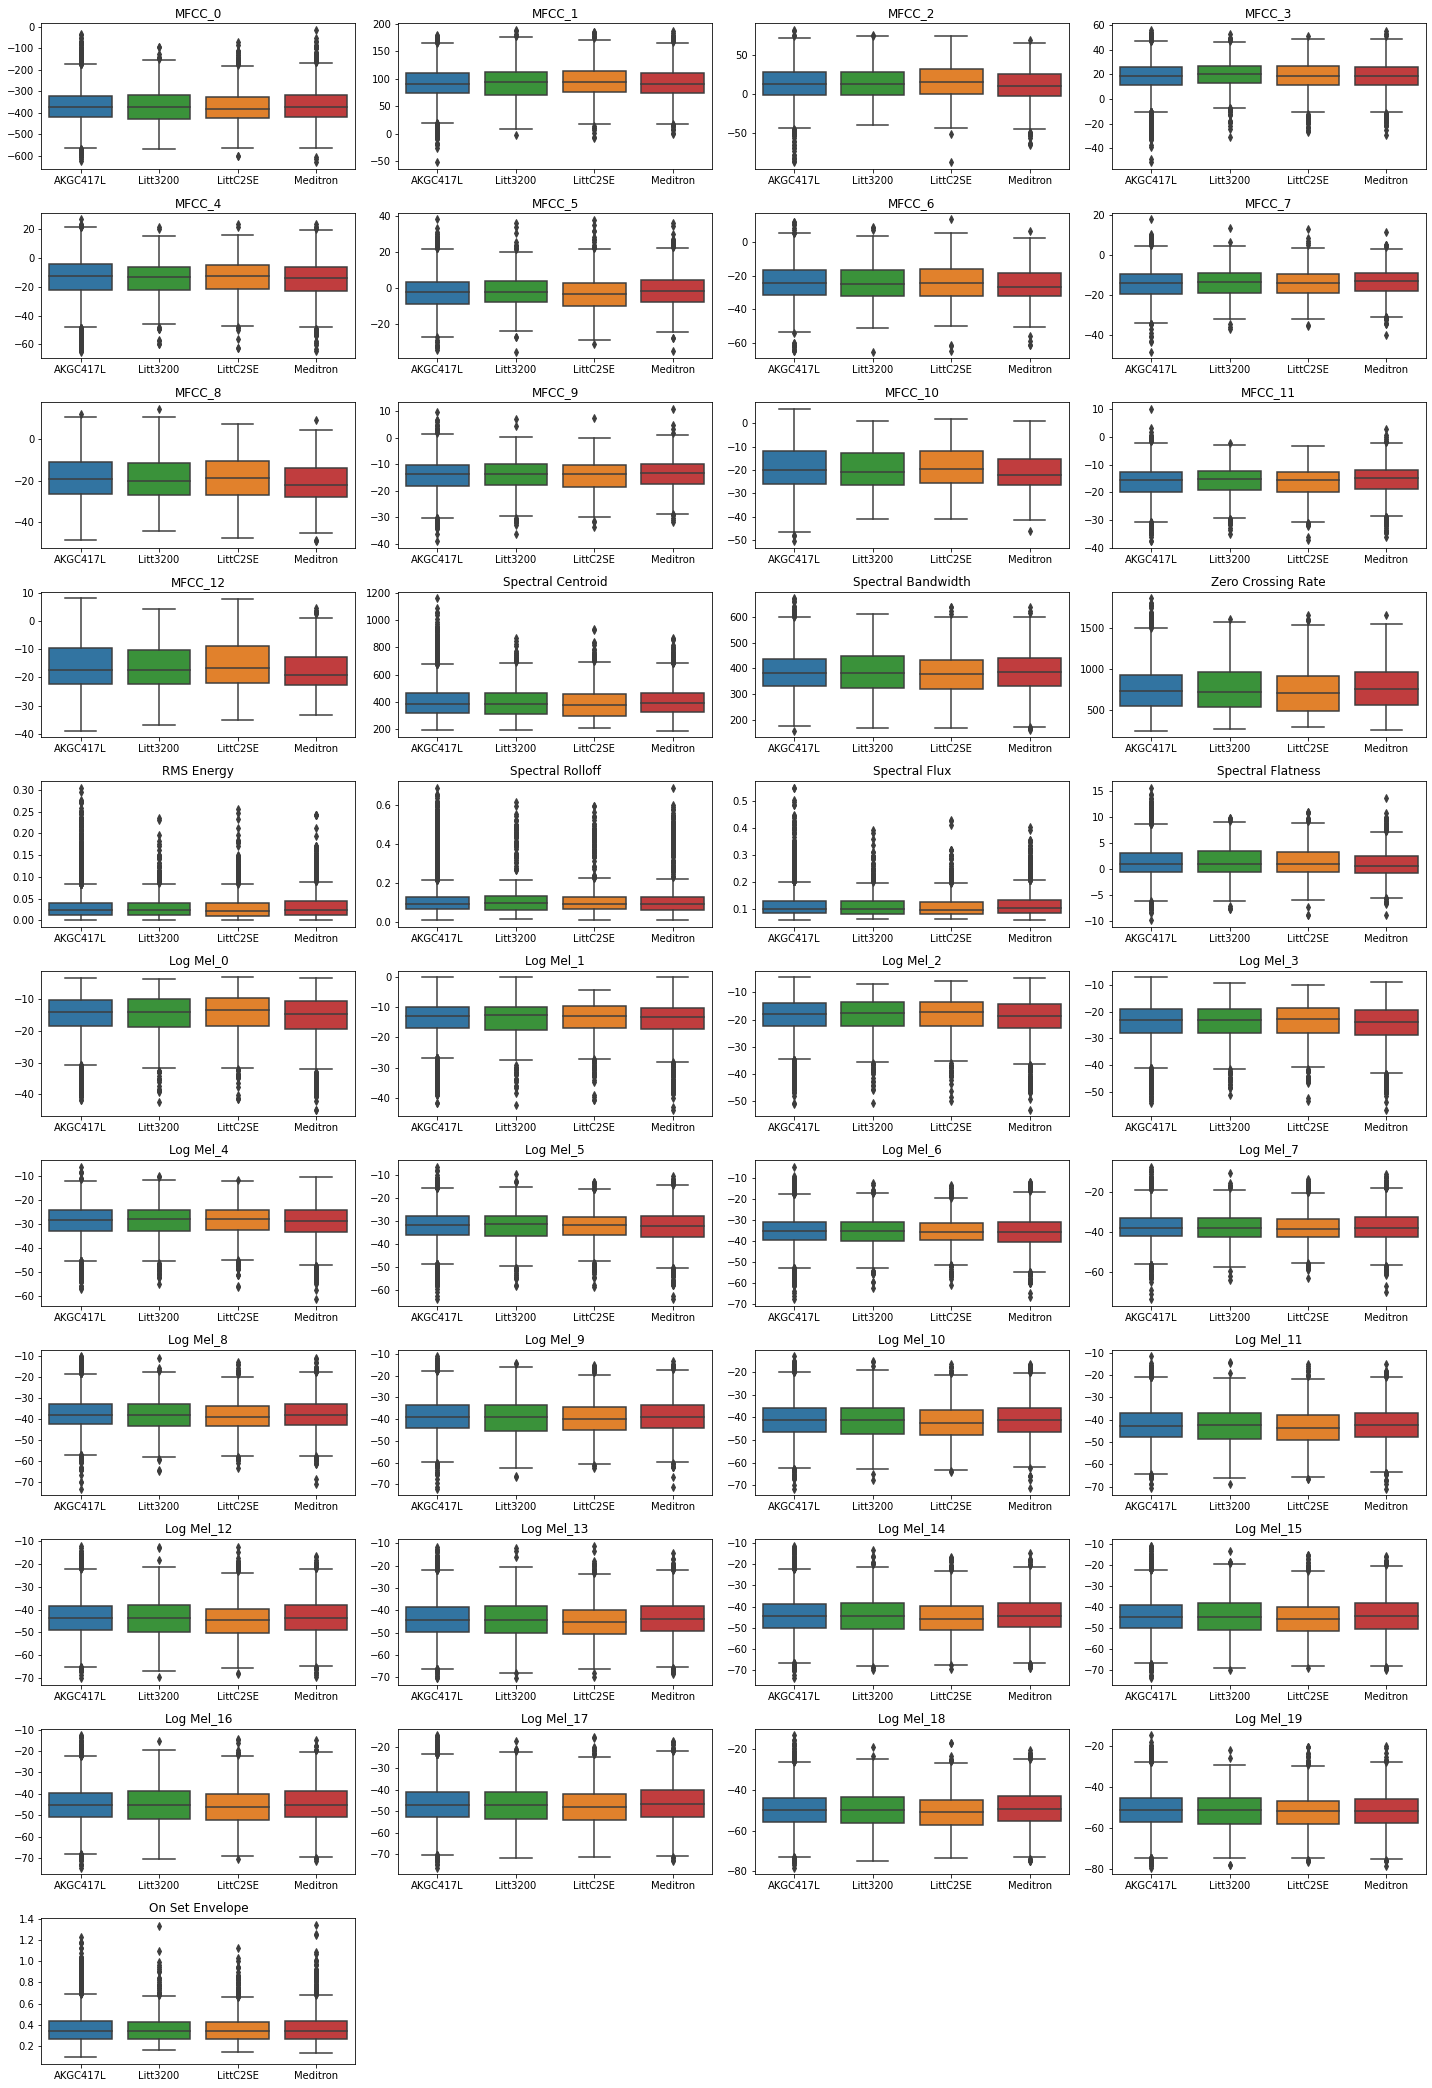

In [102]:
from utils.plots import plot_feature_distributions_by_device

training_features_sc = np.load("training_features_sc.npy")  
training_devices = np.load("training_devices.npy")  

plot_feature_distributions_by_device(training_features_sc, training_devices, FEATURE_NAMES)

In [103]:
from utils.metrics import mean_wasserstein

x_before = np.load("training_features_mean.npy")               
x_after = np.load("training_features_sc.npy")        
devices = np.load("training_devices.npy", allow_pickle=True) 

# Results per device
results = {}

for device in DEVICES:
    if device == REFERENCE_DEVICE:
        continue

    X_src_before = x_before[devices == device]
    X_src_after  = x_after[devices == device]
    X_trg_before = x_before[devices == REFERENCE_DEVICE]
    X_trg_after  = x_after[devices == REFERENCE_DEVICE]

    # Calculate the Wasserstein  distance of the 3 remaining devices from AKGC417L 
    dist_before = mean_wasserstein(X_src_before, X_trg_before)
    dist_after  = mean_wasserstein(X_src_after, X_trg_after)
    reduction   = (dist_before - dist_after) / dist_before

    results[device] = {
        "before": dist_before,
        "after": dist_after,
        "reduction_ratio": reduction
    }

for device, vals in results.items():
    print(f"[{device} → {REFERENCE_DEVICE}]")
    print(f"Wasserstein distance before: {vals['before']:.4f}")
    print(f"Wasserstein distance after:  {vals['after']:.4f}")
    print(f"Wasserstein relevant reduction: {abs(100 * vals['reduction_ratio']):.2f}%\n")

[AKGC417L → Meditron]
Wasserstein distance before: 5.0414
Wasserstein distance after:  1.4294
Wasserstein relevant reduction: 71.65%

[LittC2SE → Meditron]
Wasserstein distance before: 11.5904
Wasserstein distance after:  3.0465
Wasserstein relevant reduction: 73.72%

[Litt3200 → Meditron]
Wasserstein distance before: 25.9013
Wasserstein distance after:  1.7234
Wasserstein relevant reduction: 93.35%



In [104]:
from utils.metrics import mean_js_divergence

results_js = {}

for device in DEVICES:
    if device == REFERENCE_DEVICE:
        continue

    X_src_before = x_before[devices == device]
    X_src_after  = x_after[devices == device]
    X_trg_before = x_before[devices == REFERENCE_DEVICE]
    X_trg_after  = x_after[devices == REFERENCE_DEVICE]

    dist_before = mean_js_divergence(X_src_before, X_trg_before)
    dist_after  = mean_js_divergence(X_src_after, X_trg_after)
    reduction   = (dist_before - dist_after) / dist_before

    results_js[device] = {
        "before": dist_before,
        "after": dist_after,
        "reduction_ratio": reduction
    }

for device, vals in results_js.items():
    print(f"[{device} → {REFERENCE_DEVICE}]")
    print(f"JS divergence before: {vals['before']:.4f}")
    print(f"JS divergence after:  {vals['after']:.4f}")
    print(f"JS relevant reduction: {abs(100 * vals['reduction_ratio']):.2f}%\n")

[AKGC417L → Meditron]
JS divergence before: 0.2264
JS divergence after:  0.1229
JS relevant reduction: 45.72%

[LittC2SE → Meditron]
JS divergence before: 0.2923
JS divergence after:  0.1902
JS relevant reduction: 34.93%

[Litt3200 → Meditron]
JS divergence before: 0.6171
JS divergence after:  0.1995
JS relevant reduction: 67.67%



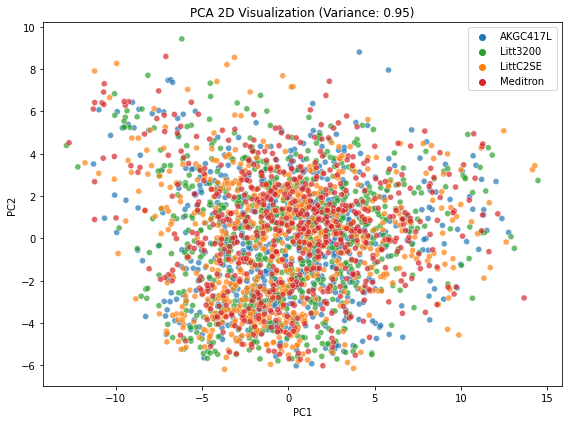

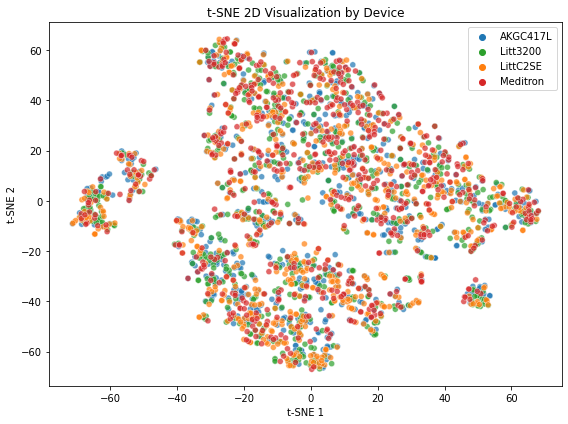

In [19]:
from utils.plots import perform_pca_and_tsne_by_device

training_features_sc = np.load("training_features_sc.npy")  

# Count samples per device
device_counts = Counter(training_devices)
min_count = min(device_counts.values())  # minimum class count

# Select balanced subset by resampling
balanced_training_features = []
balanced_device_labels = []

for device in np.unique(training_devices):
    training_features_dev = training_features_sc[training_devices == device]
    training_features_bal = resample(training_features_dev, replace=False, n_samples=min_count, random_state=0)
    balanced_training_features.append(training_features_bal)
    balanced_device_labels.extend([device] * len(training_features_bal))

balanced_training_features = np.vstack(balanced_training_features)
balanced_device_labels = np.array(balanced_device_labels)

perform_pca_and_tsne_by_device(
    balanced_training_features,
    balanced_device_labels,
    pca_components=0.95,  
    tsne_components=2,
    perplexity=30,
    feature_names=FEATURE_NAMES,
    plot_feature_contribution=False
)

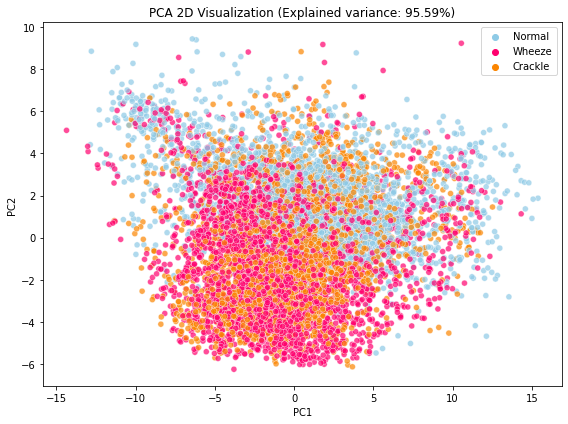

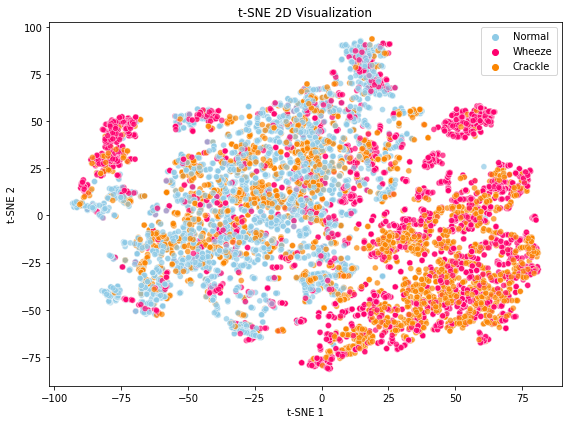

In [48]:
from utils.plots import perform_pca_and_tsne

training_features_sc = np.load("training_features_sc.npy")
training_labels_sc = np.load("training_labels_sc.npy")

perform_pca_and_tsne(
    feature_matrix=training_features_sc,  # shape: (cycles, features)
    labels=training_labels_sc,           # shape: (cycles,)
    pca_components=0.95,  # 95% variance
    tsne_components=2,
    perplexity=30,
    feature_names=FEATURE_NAMES,
    plot_feature_contribution=False
)

Accuracy per fold: [0.3036 0.2808 0.2795 0.3308 0.3498]
Mean Domain Classification Accuracy: 0.3089 ± 0.0277


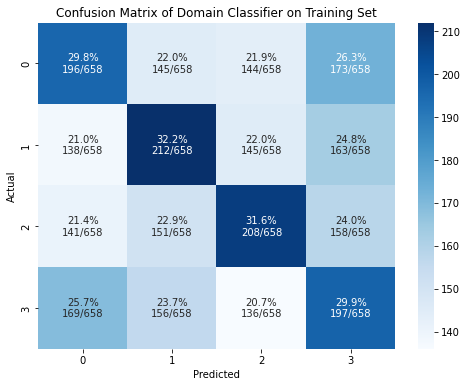

In [18]:
training_features_sc = np.load("training_features_sc.npy")  
device_labels = np.load("training_devices.npy")   

# Count samples per device
device_counts = Counter(device_labels)
min_count = min(device_counts.values())  # minimum class count

# Select balanced subset by resampling
balanced_training_features = []
balanced_device_labels = []

for device in np.unique(device_labels):
    training_features_dev = training_features_sc[device_labels == device]
    training_features_bal = resample(training_features_dev, replace=False, n_samples=min_count, random_state=0)
    balanced_training_features.append(training_features_bal)
    balanced_device_labels.extend([device] * len(training_features_bal))

balanced_training_features = np.vstack(balanced_training_features)
balanced_device_labels = np.array(balanced_device_labels)

# Encode device labels
le = LabelEncoder()
y = le.fit_transform(balanced_device_labels)
device_names = le.classes_

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(balanced_training_features)

# Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')
print("Accuracy per fold:", np.round(scores, 4))
print("Mean Domain Classification Accuracy: {:.4f} ± {:.4f}".format(scores.mean(), scores.std()))

# Predictions for confusion matrix
y_pred = cross_val_predict(clf, X, y, cv=cv)

# Confusion matrix
cm = confusion_matrix(y, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

labels = np.array([
    [f"{cm_norm[i, j]*100:.1f}%\n{cm[i, j]}/{cm.sum(axis=1)[i]}" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', cbar=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Domain Classifier on Training Set")
plt.show()

#### **DANN**

Load data and build the architectures for each module.

In [ ]:
from domain_adaptation_algorithms.dann import FeatureExtractor, LabelClassifier, DomainClassifier, DomainClassifierWrapper
from utils.neural_networks import load_data, build_models, print_model_summary

data = load_data()
input_dim = data["X_train"].shape[1] # Number of input features
n_classes = data["n_classes"] # Number of classes
n_domains = data["n_domains"] # Number of domains
bottleneck_dim = BOTTLENECK
batch_size = BATCH_SIZE

modules = build_models(
    model="dann",
    input_dim=input_dim,
    bottleneck=bottleneck_dim,
    n_classes=n_classes,
    n_domains=n_domains,
    FeatureExtractor=FeatureExtractor,
    LabelClassifier=LabelClassifier,
    DomainClassifier=DomainClassifier
)
G, C, D = modules["G"], modules["C"], modules["D"]

print_model_summary("Feature Extractor", G, input_size=(batch_size, input_dim))
print_model_summary("Label Classifier", C, input_size=(batch_size, bottleneck_dim))
print_model_summary("Domain Classifier", DomainClassifierWrapper(D, alpha=1.0), input_size=(batch_size, bottleneck_dim))

### Feature Extractor

Layer (type:depth-idx)                   Output Shape              Param #
FeatureExtractor                         --                        --
├─Sequential: 1-1                        [64, 256]                 --
│    └─Linear: 2-1                       [64, 64]                  2,688
│    └─BatchNorm1d: 2-2                  [64, 64]                  128
│    └─ReLU: 2-3                         [64, 64]                  --
│    └─Dropout: 2-4                      [64, 64]                  --
│    └─Linear: 2-5                       [64, 128]                 8,320
│    └─BatchNorm1d: 2-6                  [64, 128]                 256
│    └─ReLU: 2-7                         [64, 128]                 --
│    └─Dropout: 2-8                      [64, 128]                 --
│    └─Linear: 2-9                       [64, 256]                 33,024
│    └─BatchNorm1d: 2-10                 [64, 256]                 512
│    └─ReLU: 2-11                        [64, 256]                 --
To

### Label Classifier

Layer (type:depth-idx)                   Output Shape              Param #
LabelClassifier                          --                        --
├─Sequential: 1-1                        [64, 3]                   --
│    └─Linear: 2-1                       [64, 128]                 32,896
│    └─BatchNorm1d: 2-2                  [64, 128]                 256
│    └─ReLU: 2-3                         [64, 128]                 --
│    └─Dropout: 2-4                      [64, 128]                 --
│    └─Linear: 2-5                       [64, 64]                  8,256
│    └─BatchNorm1d: 2-6                  [64, 64]                  128
│    └─ReLU: 2-7                         [64, 64]                  --
│    └─Linear: 2-8                       [64, 3]                   195
Total params: 41,731
Trainable params: 41,731
Non-trainable params: 0
Total mult-adds (M): 2.67
Input size (MB): 0.07
Forward/backward pass size (MB): 0.20
Params size (MB): 0.17
Estimated Total Size (MB): 0.43


### Domain Classifier

Layer (type:depth-idx)                   Output Shape              Param #
DomainClassifierWrapper                  --                        --
├─DomainClassifier: 1-1                  [64, 4]                   --
│    └─Sequential: 2-1                   [64, 4]                   --
│    │    └─Linear: 3-1                  [64, 128]                 32,896
│    │    └─BatchNorm1d: 3-2             [64, 128]                 256
│    │    └─ReLU: 3-3                    [64, 128]                 --
│    │    └─Dropout: 3-4                 [64, 128]                 --
│    │    └─Linear: 3-5                  [64, 64]                  8,256
│    │    └─BatchNorm1d: 3-6             [64, 64]                  128
│    │    └─ReLU: 3-7                    [64, 64]                  --
│    │    └─Linear: 3-8                  [64, 4]                   260
Total params: 41,796
Trainable params: 41,796
Non-trainable params: 0
Total mult-adds (M): 2.67
Input size (MB): 0.07
Forward/backward pass size 

Train the model, plot the loss curves and save the extracted embeddings from the trained feature extractor.

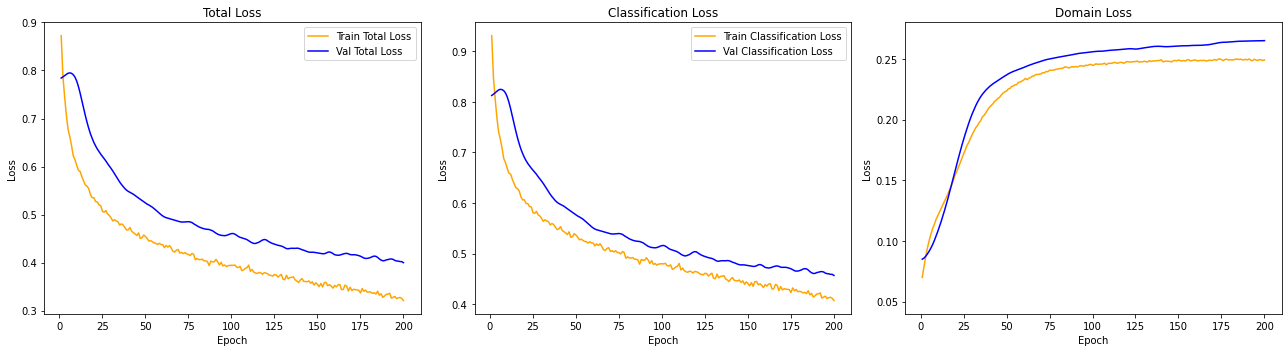

In [ ]:
from domain_adaptation_algorithms.dann import train_dann
from utils.neural_networks import plot_losses

logs, emb_train, emb_test = train_dann(G, C, D, data, lambda_domain=0.1, epochs=200)

plot_losses(logs)

np.save("dann_embeddings_train.npy", emb_train)
np.save("dann_embeddings_test.npy", emb_test)

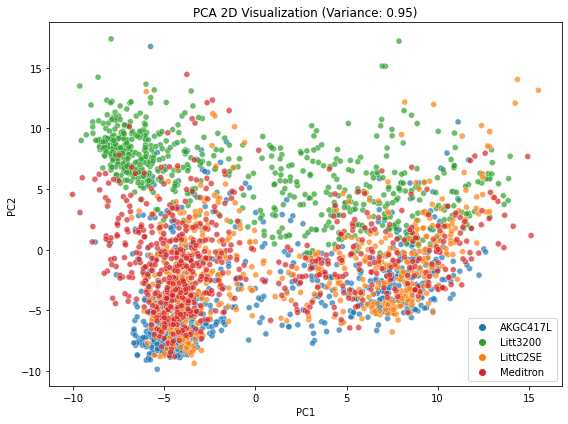

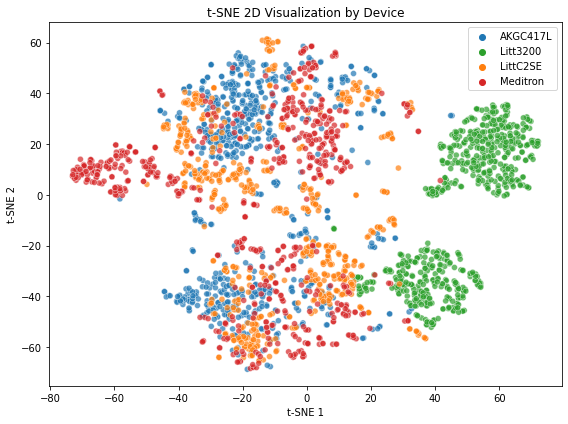

In [13]:
from utils.plots import perform_pca_and_tsne_by_device

# Count samples per device
device_counts = Counter(training_devices)
min_count = min(device_counts.values())  # minimum class count

# Select balanced subset by resampling
balanced_training_features = []
balanced_device_labels = []

for device in np.unique(training_devices):
    training_features_dev = emb_train[training_devices == device]
    training_features_bal = resample(training_features_dev, replace=False, n_samples=min_count, random_state=0)
    balanced_training_features.append(training_features_bal)
    balanced_device_labels.extend([device] * len(training_features_bal))

balanced_training_features = np.vstack(balanced_training_features)
balanced_device_labels = np.array(balanced_device_labels)

perform_pca_and_tsne_by_device(
    balanced_training_features,
    balanced_device_labels,
    pca_components=0.95,  
    tsne_components=2,
    perplexity=30,
    feature_names=FEATURE_NAMES,
    plot_feature_contribution=False
)

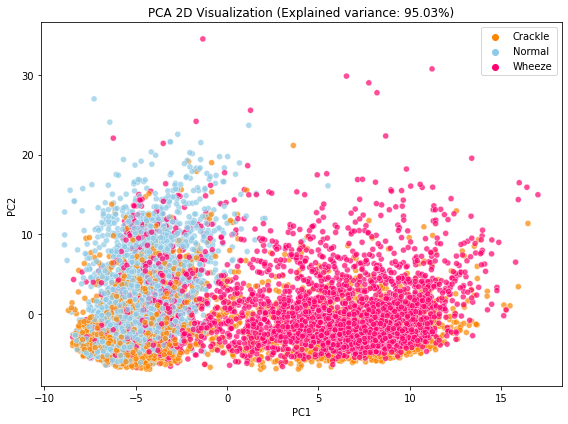

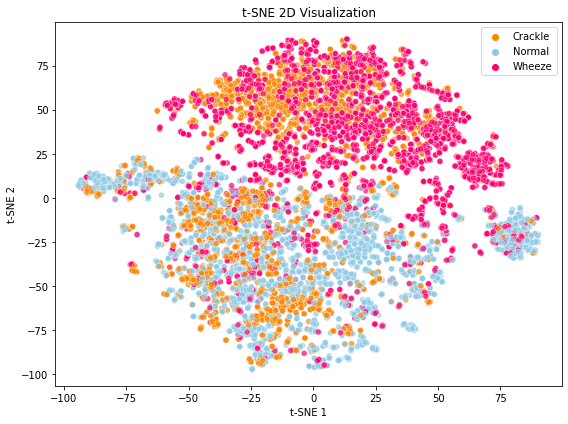

In [14]:
from utils.plots import perform_pca_and_tsne

training_labels = np.load("training_labels.npy")

perform_pca_and_tsne(
    feature_matrix=emb_train, 
    labels=training_labels,           
    pca_components=0.95,  
    tsne_components=2,
    perplexity=30,
    feature_names=FEATURE_NAMES,
    plot_feature_contribution=False
)

#### **Conditional DANN (CDAN)**

In [ ]:
from domain_adaptation_algorithms.cdan import *
from domain_adaptation_algorithms.dann import DomainClassifierWrapper
from utils.neural_networks import load_data, build_models, print_model_summary

data = load_data()
input_dim = data["X_train"].shape[1] # Number of input features
n_classes = data["n_classes"] # Number of classes
n_domains = data["n_domains"] # Number of domains
bottleneck_dim = BOTTLENECK
batch_size = BATCH_SIZE

modules = build_models(
    model="cdan",
    input_dim=input_dim,
    bottleneck=bottleneck_dim,
    n_classes=n_classes,
    n_domains=n_domains,
    FeatureExtractor=FeatureExtractor,
    LabelClassifier=LabelClassifier,
    DomainClassifier=DomainClassifier
)

G, C, D = modules["G"], modules["C"], modules["D"]

print_model_summary("Feature Extractor", G, input_size=(batch_size, input_dim))
print_model_summary("Label Classifier", C, input_size=(batch_size, bottleneck_dim))
print_model_summary("Domain Classifier", DomainClassifierWrapper(D, alpha=1.0), input_size=(batch_size, bottleneck_dim * n_classes))

### Feature Extractor

Layer (type:depth-idx)                   Output Shape              Param #
FeatureExtractor                         --                        --
├─Sequential: 1-1                        [64, 256]                 --
│    └─Linear: 2-1                       [64, 128]                 5,376
│    └─BatchNorm1d: 2-2                  [64, 128]                 256
│    └─ReLU: 2-3                         [64, 128]                 --
│    └─Dropout: 2-4                      [64, 128]                 --
│    └─Linear: 2-5                       [64, 256]                 33,024
│    └─BatchNorm1d: 2-6                  [64, 256]                 512
│    └─ReLU: 2-7                         [64, 256]                 --
Total params: 39,168
Trainable params: 39,168
Non-trainable params: 0
Total mult-adds (M): 2.51
Input size (MB): 0.01
Forward/backward pass size (MB): 0.39
Params size (MB): 0.16
Estimated Total Size (MB): 0.56


### Label Classifier

Layer (type:depth-idx)                   Output Shape              Param #
LabelClassifier                          --                        --
├─Sequential: 1-1                        [64, 3]                   --
│    └─Linear: 2-1                       [64, 128]                 32,896
│    └─ReLU: 2-2                         [64, 128]                 --
│    └─Dropout: 2-3                      [64, 128]                 --
│    └─Linear: 2-4                       [64, 3]                   387
Total params: 33,283
Trainable params: 33,283
Non-trainable params: 0
Total mult-adds (M): 2.13
Input size (MB): 0.07
Forward/backward pass size (MB): 0.07
Params size (MB): 0.13
Estimated Total Size (MB): 0.27


### Domain Classifier

Layer (type:depth-idx)                   Output Shape              Param #
DomainClassifierWrapper                  --                        --
├─DomainClassifier: 1-1                  [64, 4]                   --
│    └─Sequential: 2-1                   [64, 4]                   --
│    │    └─Linear: 3-1                  [64, 128]                 98,432
│    │    └─BatchNorm1d: 3-2             [64, 128]                 256
│    │    └─ReLU: 3-3                    [64, 128]                 --
│    │    └─Linear: 3-4                  [64, 64]                  8,256
│    │    └─BatchNorm1d: 3-5             [64, 64]                  128
│    │    └─ReLU: 3-6                    [64, 64]                  --
│    │    └─Linear: 3-7                  [64, 4]                   260
Total params: 107,332
Trainable params: 107,332
Non-trainable params: 0
Total mult-adds (M): 6.87
Input size (MB): 0.20
Forward/backward pass size (MB): 0.20
Params size (MB): 0.43
Estimated Total Size (MB): 0.82


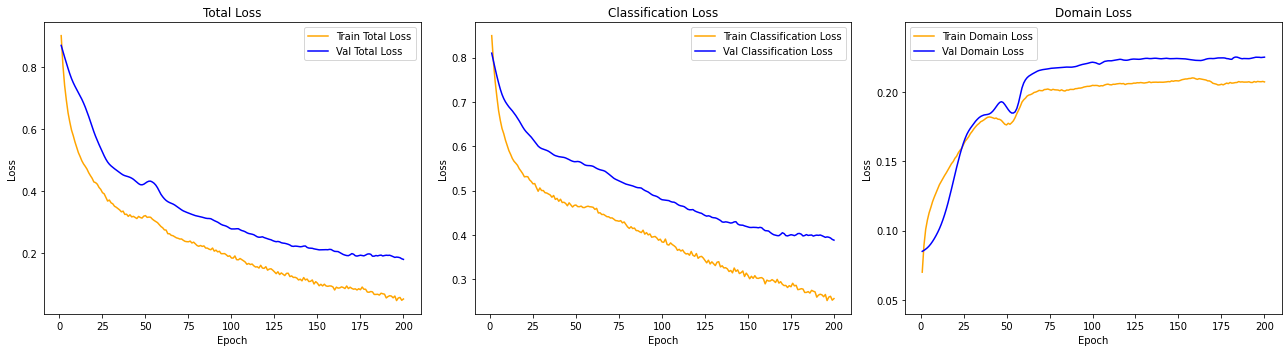

In [ ]:
from domain_adaptation_algorithms.cdan import train_cdan
from utils.neural_networks import plot_losses

logs, emb_train, emb_test = train_cdan(G, C, D, data, lambda_domain=0.2, epochs=200)

plot_losses(logs)

np.save("cdan_embeddings_train.npy", emb_train)
np.save("cdan_embeddings_test.npy", emb_test)

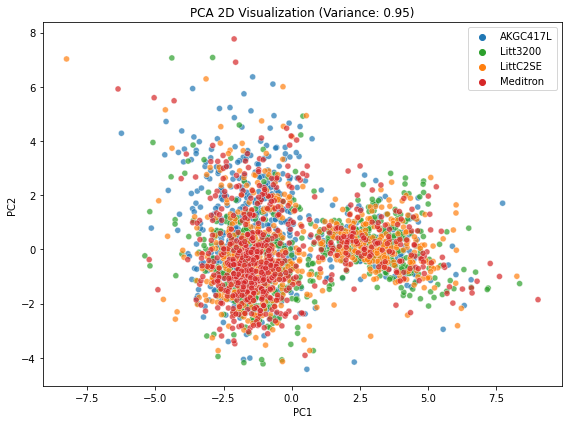

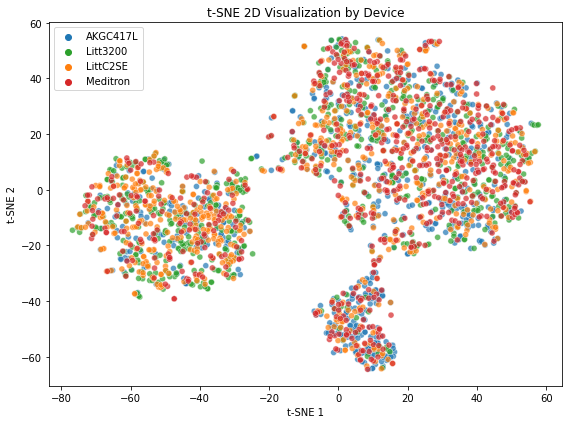

In [18]:
from utils.plots import perform_pca_and_tsne_by_device

# Count samples per device
device_counts = Counter(training_devices)
min_count = min(device_counts.values())  # minimum class count

# Select balanced subset by resampling
balanced_training_features = []
balanced_device_labels = []

for device in np.unique(training_devices):
    training_features_dev = emb_train[training_devices == device]
    training_features_bal = resample(training_features_dev, replace=False, n_samples=min_count, random_state=0)
    balanced_training_features.append(training_features_bal)
    balanced_device_labels.extend([device] * len(training_features_bal))

balanced_training_features = np.vstack(balanced_training_features)
balanced_device_labels = np.array(balanced_device_labels)

perform_pca_and_tsne_by_device(
    balanced_training_features,
    balanced_device_labels,
    pca_components=0.95,  
    tsne_components=2,
    perplexity=30,
    feature_names=FEATURE_NAMES,
    plot_feature_contribution=False
)

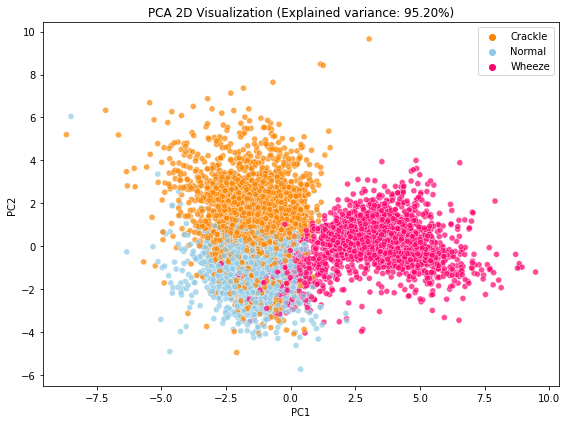

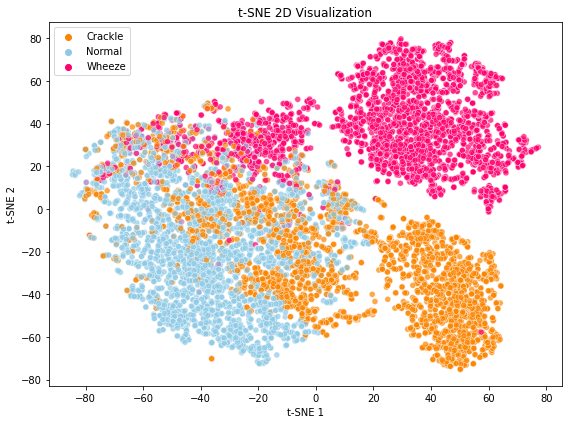

In [ ]:
from utils.plots import perform_pca_and_tsne

training_labels = np.load("training_labels.npy")

perform_pca_and_tsne(
    feature_matrix=emb_train,  # shape: (cycles, features)
    labels=training_labels,           # shape: (cycles,)
    pca_components=0.95,  # 95% variance
    tsne_components=2,
    perplexity=30,
    feature_names=FEATURE_NAMES,
    plot_feature_contribution=False
)

#### **DANN with VAE**

1 Phase training

In [ ]:
from domain_adaptation_algorithms.davae import *
from domain_adaptation_algorithms.dann import DomainClassifierWrapper
from utils.neural_networks import load_data, print_model_summary

data = load_data()
input_dim = data["X_train"].shape[1] # Number of input features
n_classes = data["n_classes"] # Number of classes
n_domains = data["n_domains"] # Number of domains
latent_dim = LATENT
batch_size = BATCH_SIZE

modules = build_models(
    model="davae",
    input_dim=input_dim,
    latent_dim=latent_dim,
    n_classes=n_classes,
    n_domains=n_domains,
    Encoder=Encoder,
    Decoder=Decoder,
    LabelClassifier=LabelClassifier,
    DomainClassifier=DomainClassifier
)

encoder, decoder, C, D = modules["Enc"], modules["Dec"], modules["C"], modules["D"]

print_model_summary("Encoder", encoder, input_size=(batch_size, input_dim))
print_model_summary("Decoder", decoder, input_size=(batch_size, latent_dim))
print_model_summary("Label Classifier", C, input_size=(batch_size, latent_dim))
print_model_summary("Domain Classifier", DomainClassifierWrapper(D, alpha=1.0), input_size=(batch_size, latent_dim))

### Encoder

Layer (type:depth-idx)                   Output Shape              Param #
Encoder                                  --                        --
├─Sequential: 1-1                        [64, 256]                 --
│    └─Linear: 2-1                       [64, 512]                 21,504
│    └─ReLU: 2-2                         [64, 512]                 --
│    └─Linear: 2-3                       [64, 256]                 131,328
│    └─ReLU: 2-4                         [64, 256]                 --
├─Linear: 1-2                            [64, 16]                  4,112
├─Linear: 1-3                            [64, 16]                  4,112
Total params: 161,056
Trainable params: 161,056
Non-trainable params: 0
Total mult-adds (M): 10.31
Input size (MB): 0.01
Forward/backward pass size (MB): 0.41
Params size (MB): 0.64
Estimated Total Size (MB): 1.06


### Decoder

Layer (type:depth-idx)                   Output Shape              Param #
Decoder                                  --                        --
├─Sequential: 1-1                        [64, 41]                  --
│    └─Linear: 2-1                       [64, 256]                 4,352
│    └─ReLU: 2-2                         [64, 256]                 --
│    └─Linear: 2-3                       [64, 41]                  10,537
Total params: 14,889
Trainable params: 14,889
Non-trainable params: 0
Total mult-adds (M): 0.95
Input size (MB): 0.00
Forward/backward pass size (MB): 0.15
Params size (MB): 0.06
Estimated Total Size (MB): 0.22


### Label Classifier

Layer (type:depth-idx)                   Output Shape              Param #
LabelClassifier                          --                        --
├─Sequential: 1-1                        [64, 3]                   --
│    └─Linear: 2-1                       [64, 128]                 2,176
│    └─BatchNorm1d: 2-2                  [64, 128]                 256
│    └─ReLU: 2-3                         [64, 128]                 --
│    └─Dropout: 2-4                      [64, 128]                 --
│    └─Linear: 2-5                       [64, 64]                  8,256
│    └─BatchNorm1d: 2-6                  [64, 64]                  128
│    └─ReLU: 2-7                         [64, 64]                  --
│    └─Dropout: 2-8                      [64, 64]                  --
│    └─Linear: 2-9                       [64, 3]                   195
Total params: 11,011
Trainable params: 11,011
Non-trainable params: 0
Total mult-adds (M): 0.70
Input size (MB): 0.00
Forward/backward pass size (

### Domain Classifier

Layer (type:depth-idx)                   Output Shape              Param #
DomainClassifierWrapper                  --                        --
├─DomainClassifier: 1-1                  [64, 4]                   --
│    └─Sequential: 2-1                   [64, 4]                   --
│    │    └─Linear: 3-1                  [64, 64]                  1,088
│    │    └─BatchNorm1d: 3-2             [64, 64]                  128
│    │    └─ReLU: 3-3                    [64, 64]                  --
│    │    └─Dropout: 3-4                 [64, 64]                  --
│    │    └─Linear: 3-5                  [64, 4]                   260
Total params: 1,476
Trainable params: 1,476
Non-trainable params: 0
Total mult-adds (M): 0.09
Input size (MB): 0.00
Forward/backward pass size (MB): 0.07
Params size (MB): 0.01
Estimated Total Size (MB): 0.08


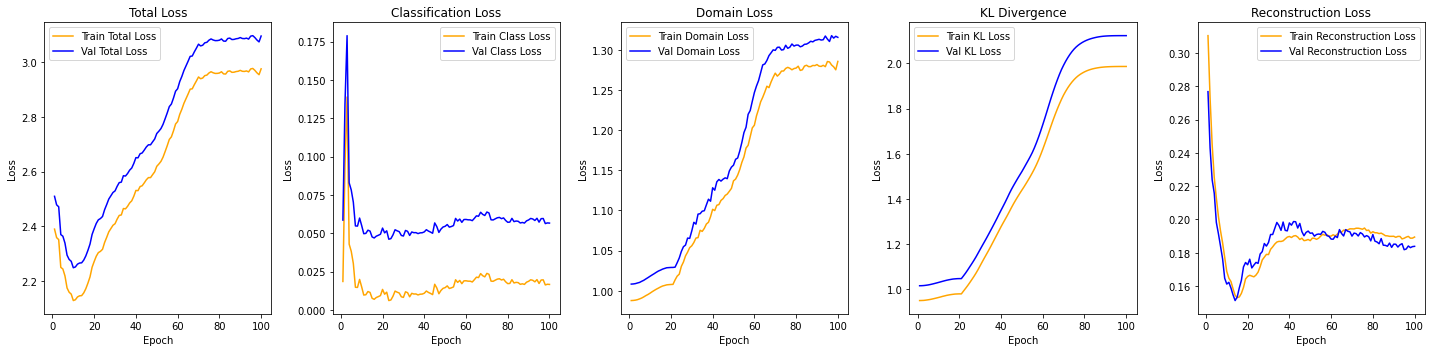

In [ ]:
from domain_adaptation_algorithms.davae import train_davae
from utils.neural_networks import plot_losses

logs, emb_train, emb_test = train_davae(encoder, decoder, C, D, data, beta=0.1, class_weight=1.0, gamma=1.0, epochs=100)

plot_losses(logs)

np.save("davae_embeddings_train.npy", emb_train)
np.save("davae_embeddings_test.npy", emb_test)

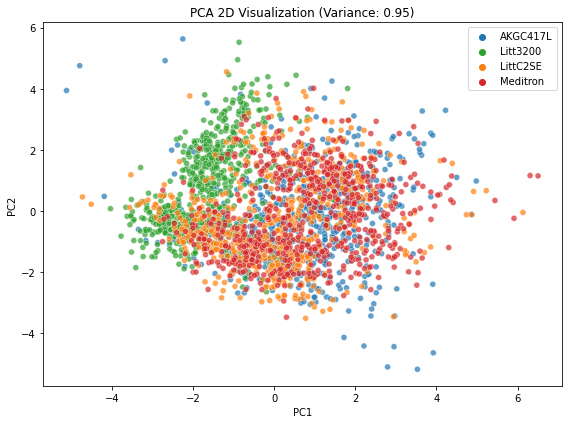

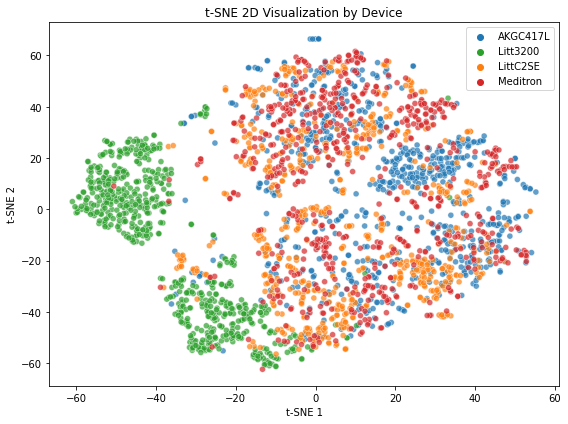

In [ ]:
from utils.plots import perform_pca_and_tsne_by_device

# Count samples per device
device_counts = Counter(training_devices)
min_count = min(device_counts.values())  # minimum class count

# Select balanced subset by resampling
balanced_training_features = []
balanced_device_labels = []

for device in np.unique(training_devices):
    training_features_dev = emb_train[training_devices == device]
    training_features_bal = resample(training_features_dev, replace=False, n_samples=min_count, random_state=0)
    balanced_training_features.append(training_features_bal)
    balanced_device_labels.extend([device] * len(training_features_bal))

balanced_training_features = np.vstack(balanced_training_features)
balanced_device_labels = np.array(balanced_device_labels)

perform_pca_and_tsne_by_device(
    balanced_training_features,
    balanced_device_labels,
    pca_components=0.95,  
    tsne_components=2,
    perplexity=30,
    feature_names=FEATURE_NAMES,
    plot_feature_contribution=False
)

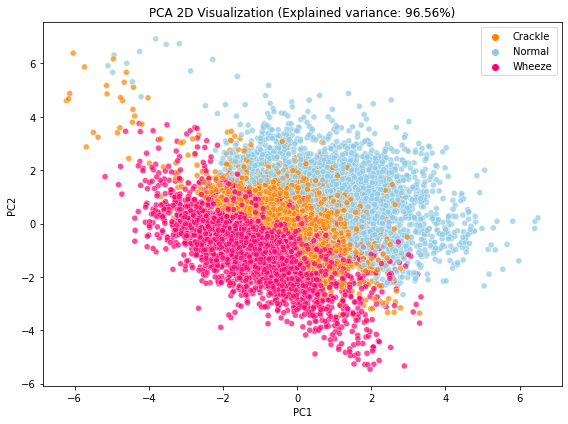

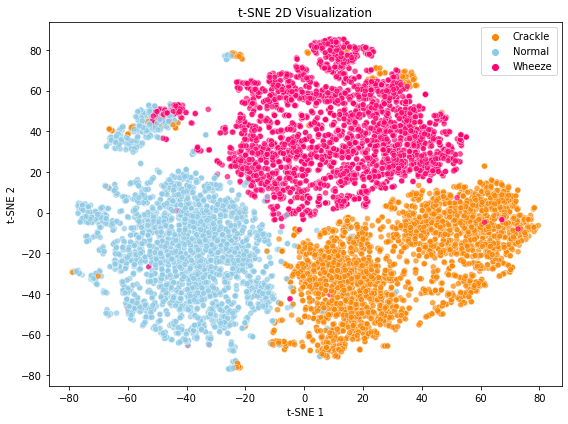

In [98]:
from utils.plots import perform_pca_and_tsne

training_labels = np.load("training_labels.npy")

perform_pca_and_tsne(
    feature_matrix=emb_train,  # shape: (cycles, features)
    labels=training_labels,           # shape: (cycles,)
    pca_components=0.95,  # 95% variance
    tsne_components=2,
    perplexity=30,
    feature_names=FEATURE_NAMES,
    plot_feature_contribution=False
)

2 phase training

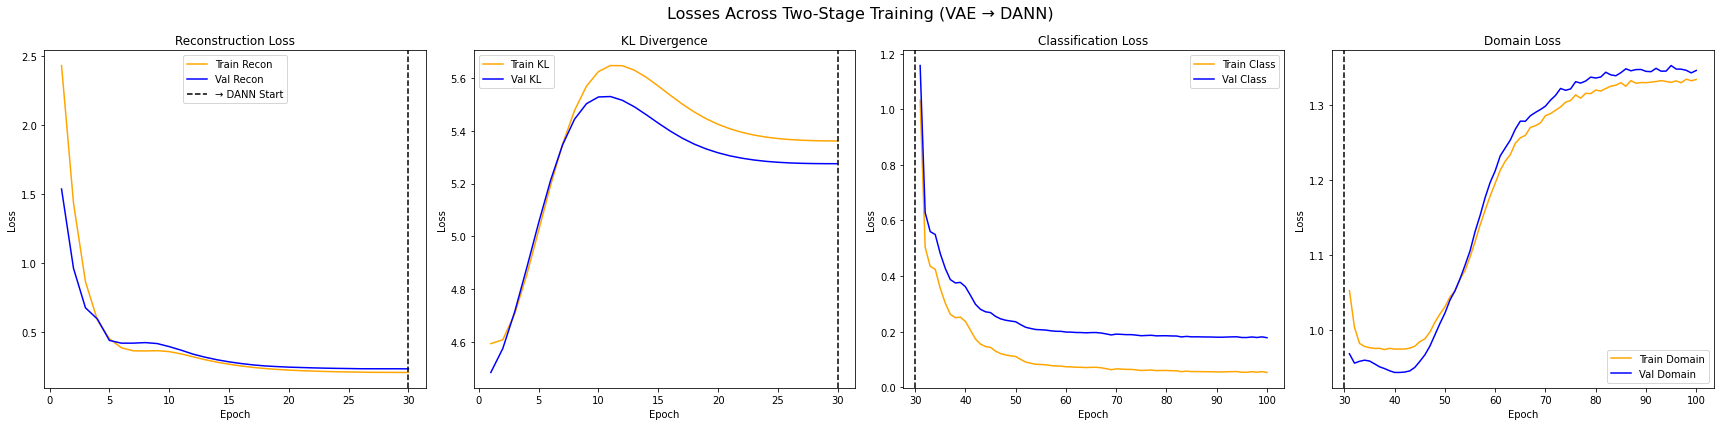

In [ ]:
from domain_adaptation_algorithms.davae import train_vae_stage, train_dann_stage
from utils.neural_networks import plot_2stage_losses

vae_logs = train_vae_stage(encoder, decoder, data, beta=0.1, epochs=30)

# Freeze decoder
decoder.eval()
for p in decoder.parameters():
    p.requires_grad = False

dann_logs, emb_train, emb_test = train_dann_stage(encoder, C, D, data, class_weight=1.0, gamma=1.0, epochs=70, start_epoch=30)

plot_2stage_losses(vae_logs, dann_logs, vae_epochs=30)

np.save("davae_embeddings_train_2.npy", emb_train)
np.save("davae_embeddings_test_2.npy", emb_test)

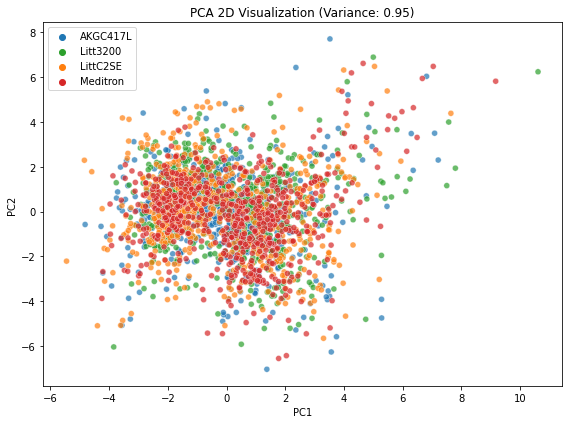

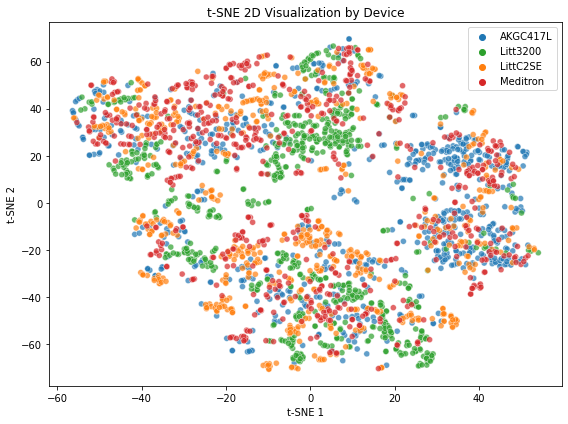

In [ ]:
from utils.plots import perform_pca_and_tsne_by_device

# Count samples per device
device_counts = Counter(training_devices)
min_count = min(device_counts.values())  # minimum class count

# Select balanced subset by resampling
balanced_training_features = []
balanced_device_labels = []

for device in np.unique(training_devices):
    training_features_dev = emb_train[training_devices == device]
    training_features_bal = resample(training_features_dev, replace=False, n_samples=min_count, random_state=0)
    balanced_training_features.append(training_features_bal)
    balanced_device_labels.extend([device] * len(training_features_bal))

balanced_training_features = np.vstack(balanced_training_features)
balanced_device_labels = np.array(balanced_device_labels)

perform_pca_and_tsne_by_device(
    balanced_training_features,
    balanced_device_labels,
    pca_components=0.95,  
    tsne_components=2,
    perplexity=30,
    feature_names=FEATURE_NAMES,
    plot_feature_contribution=False
)

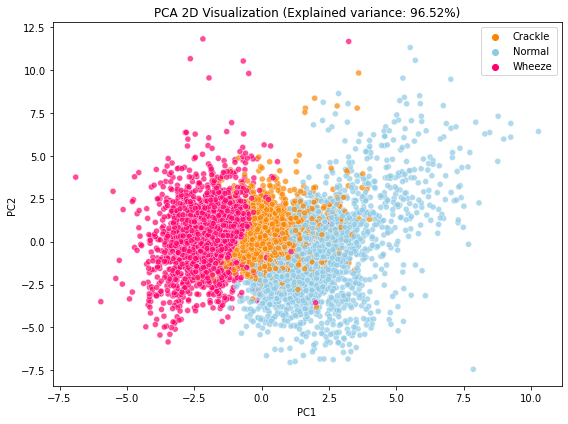

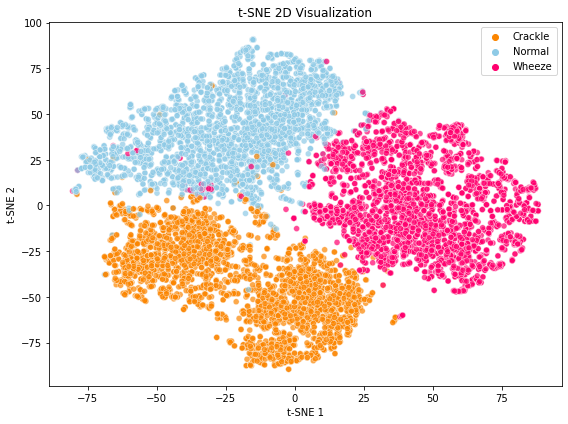

In [100]:
from utils.plots import perform_pca_and_tsne

training_labels = np.load("training_labels.npy")

perform_pca_and_tsne(
    feature_matrix=emb_train,  # shape: (cycles, features)
    labels=training_labels,           # shape: (cycles,)
    pca_components=0.95,  # 95% variance
    tsne_components=2,
    perplexity=30,
    feature_names=FEATURE_NAMES,
    plot_feature_contribution=False
)